# C9orf72

In [1]:
rm(list=ls())

In [4]:
getwd()

[1] "/Users/elsab/Documents/projects/C9orf72/analysis"

# LIBRAIRIES AND FUNCTIONS

In [3]:
library(tidyverse)
library(readxl)
library(MetBrewer)
derain <- met.brewer("Derain")
demuth <- met.brewer("Demuth")
cassatt <- met.brewer("Cassatt2")
library(patchwork)
library(ggsci)
library(ggpubr)
source("../src/ggstyles.R")

In [4]:
panels <- list(
  list(width = 0.03),
  list(width = 0.1, display = ~variable, fontface = "bold", heading = "Variable"),
  list(width = 0.01, display = ~level),
  list(width = 0.05, display = ~n, hjust = 1, heading = "N."),
  #list(width = 0.05, display = freql, width = 0.05, hjust = 1, heading = "N."),
  list(width = 0.03, item = "vline", hjust = 0.5),
  list(
    width = 0.55, item = "forest", hjust = 0.5, heading = "Odds Ratio", linetype = "dashed",
    line_x = 0
  ),
  list(width = 0.03, item = "vline", hjust = 0.5),
  list(width = 0.12, display = ~ ifelse(reference, "Reference", sprintf(
    "%0.2f (%0.2f, %0.2f)",
    trans(estimate), trans(conf.low), trans(conf.high)
  )), display_na = NA),
  list(
    width = 0.05,
    display = ~ ifelse(reference, "", format.pval(p.value, digits = 2, eps = 0.001)),
    display_na = NA, hjust = 1, heading = "p"
  ),
  list(width = 0.03)
)

# DATA

In [5]:
# Repeats
dd <- read_excel("../data/ICM_C9_expanded_rawRepeats_withClinical_2025-08-29.xlsx")
# MetaData
dc <- read_excel("../data/ICM_C9_expanded_summary_stats_withClinical_2025-08-29.xlsx")

In [6]:
dim(dd)
dim(dc)

[1] 3348    6

[1] 47 23

# Basics

In [7]:
head(dc,2)

Sample,Molecules_count,Mean,Median,SD,Mode,P90,Min,Max,Prop_gt500,⋯,Prop_gt2500,Prop_gt3000,Prop_gt3500,Prop_gt4000,Prop_gt4500,Prop_gt5000,Condition,AP,AO,Gender
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
125425,64,2196.412500000001,1943.4583333333358,1229.9551134932171,2669.733333333332,4083.7833333333338,299.5666666666657,5050.483333333337,0.984375,⋯,0.328125,0.21875,0.203125,0.109375,0.0625,0.015625,Presymptomatic,64,NA,M
125718,64,1952.4075520833335,1697.2833333333328,976.0048584062154,1278.0333333333335,3241.779999999998,231.83333333333337,5426.799999999999,0.96875,⋯,0.25,0.171875,0.078125,0.03125,0.015625,0.015625,Presymptomatic,41,NA,M


In [8]:
dim(dc)
colnames(dc)
length(unique(dc$Sample))

[1] 47 23

[1] "Sample"          "Molecules_count" "Mean"            "Median"         
 [5] "SD"              "Mode"            "P90"             "Min"            
 [9] "Max"             "Prop_gt500"      "Prop_gt1000"     "Prop_gt1500"    
[13] "Prop_gt2000"     "Prop_gt2500"     "Prop_gt3000"     "Prop_gt3500"    
[17] "Prop_gt4000"     "Prop_gt4500"     "Prop_gt5000"     "Condition"      
[21] "AP"              "AO"              "Gender"

[1] 47

In [9]:
table(dc$Condition, exclude=F)


           ALS            FTD Presymptomatic 
            17             23              7 

## Remove Presymptomatic

In [23]:
dc <- dc %>% filter(Condition %in% c("ALS","FTD"))
dd <- dd %>% filter(Sample %in% dc$Sample)

In [24]:
table(dc$Condition, exclude=F)


ALS FTD 
 17  23 

In [25]:
table(dc$Gender, exclude=F)


 F  M 
20 20 

In [26]:
table(dc$Condition, dc$Gender, exclude=F)

     
       F  M
  ALS  9  8
  FTD 11 12

In [27]:
summary(dc$AP)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  36.00   56.00   65.00   64.22   72.25   89.00 

In [28]:
dc$AO <- as.numeric(dc$AO)

In [29]:
summary(dc$AO)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  35.00   53.75   61.00   59.55   66.25   85.00 

In [30]:
head(dd,2)

Sample,repeats,Condition,AP,AO,Gender
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
125839,2070.550,FTD,65,63,F
125839,5091.083,FTD,65,63,F


In [31]:
length(unique(dd$Sample))

[1] 40

In [32]:
dd$repeats <- as.numeric(dd$repeats)

In [33]:
summary(dd$repeats)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  70.37  968.33 1485.00 1779.95 2370.32 6629.07 

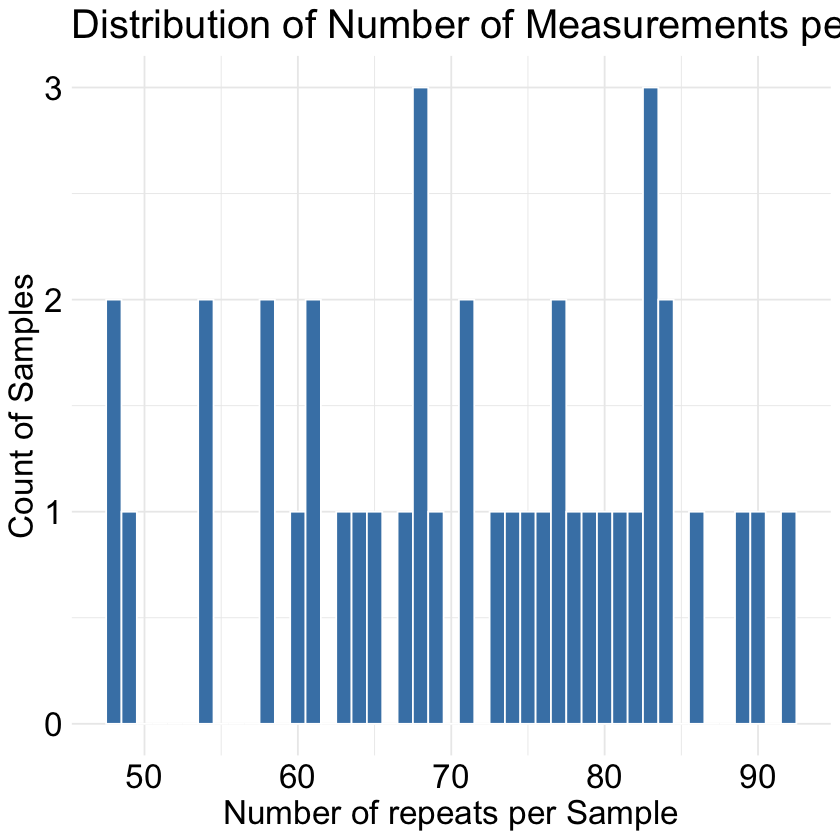

In [34]:
# Number of MUT repeats per sample
dd %>%
  #count(Sample, name = "n_repeats") %>%  # count how many measurements per sample
  group_by(Sample) %>%
  summarise(n_repeats = n()) %>%
  ungroup() %>%
  ggplot(aes(x = n_repeats)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Number of Measurements per Sample",
    x = "Number of repeats per Sample",
    y = "Count of Samples"
  ) +
  theme_minimal() + gtheme(20)

# Explore Length

## Global

In [40]:
dim(dd)

[1] 2851    6

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


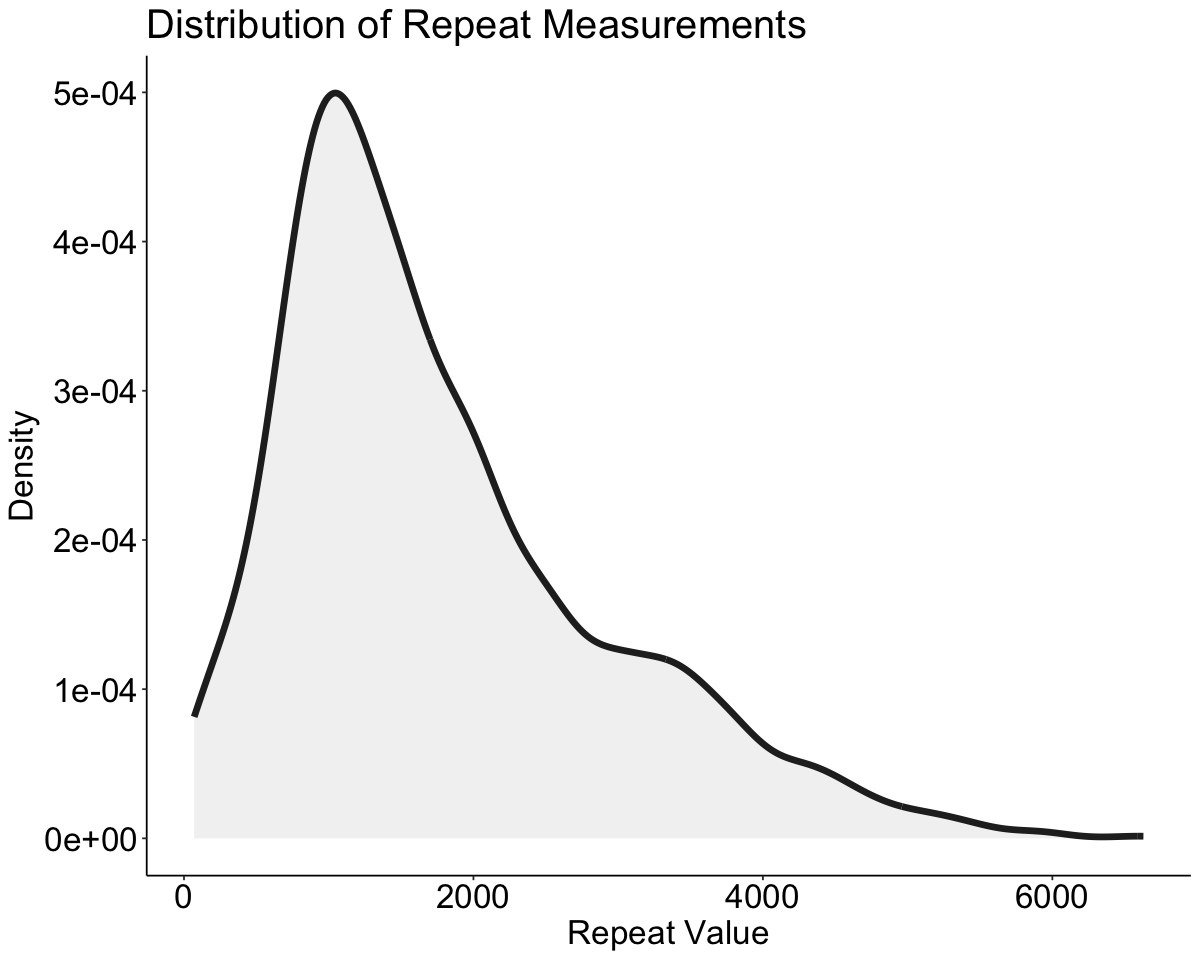

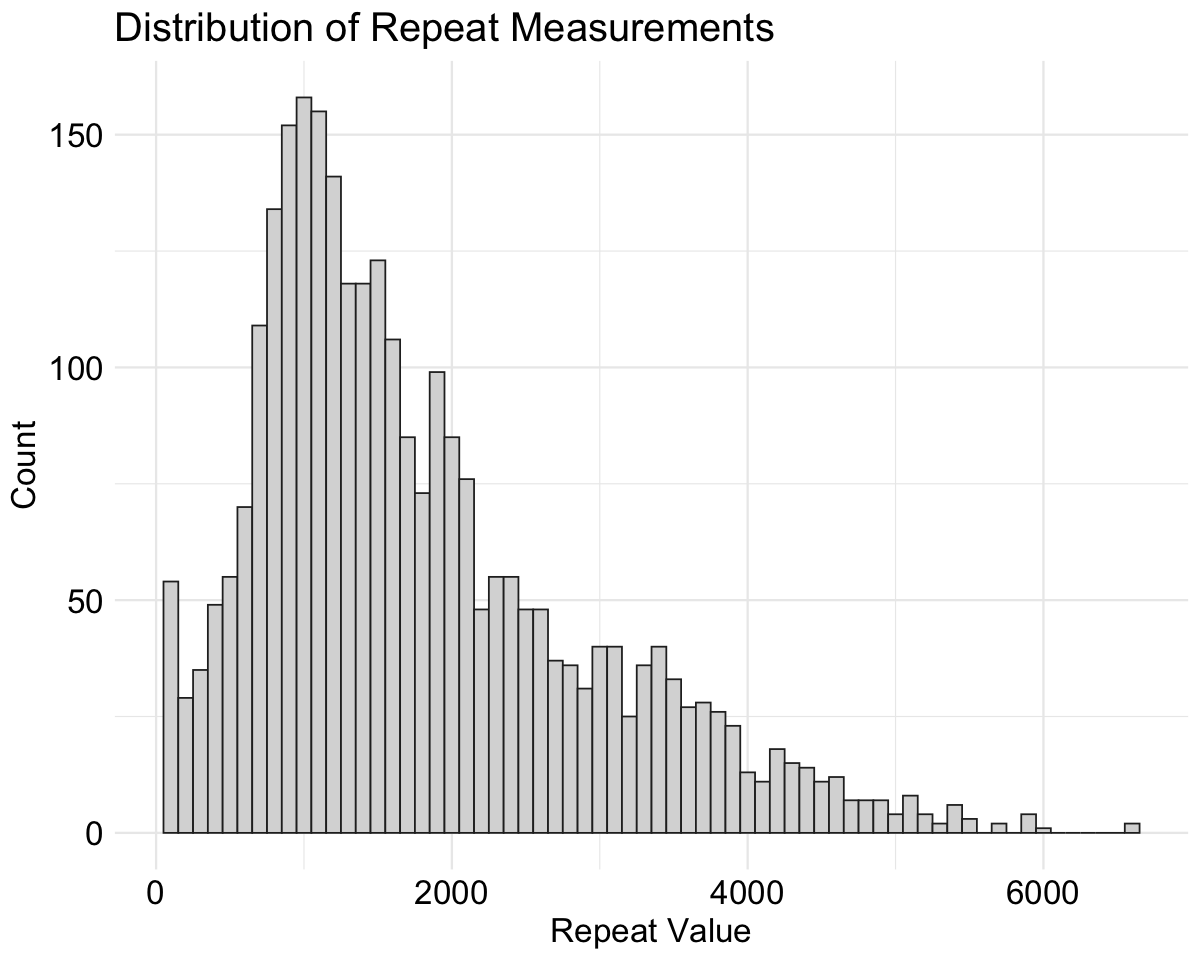

In [37]:
options(repr.plot.width=10, repr.plot.height=8)

ggplot(dd, aes(repeats)) + 
geom_density(size=1.9, fill="grey95", color="grey15")  + 
theme_classic() + gtheme(20) + 
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Density"
  )
#geom_vline(xintercept = c(147, 157, 165), linetype='dashed') + 
#scale_x_continuous(limits=c(90,300), breaks=c(100, 150, 200, 250, 300), guide = guide_axis(n.dodge = 1))

ggplot(dd, aes(x = repeats)) +
  geom_histogram(binwidth = 100, fill = "grey85", color = "grey15") +
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Count"
  ) +
  theme_minimal(base_size = 14) + gtheme(20)

In [38]:
summary(dd$repeats)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  70.37  968.33 1485.00 1779.95 2370.32 6629.07 

## Repeats x Sex

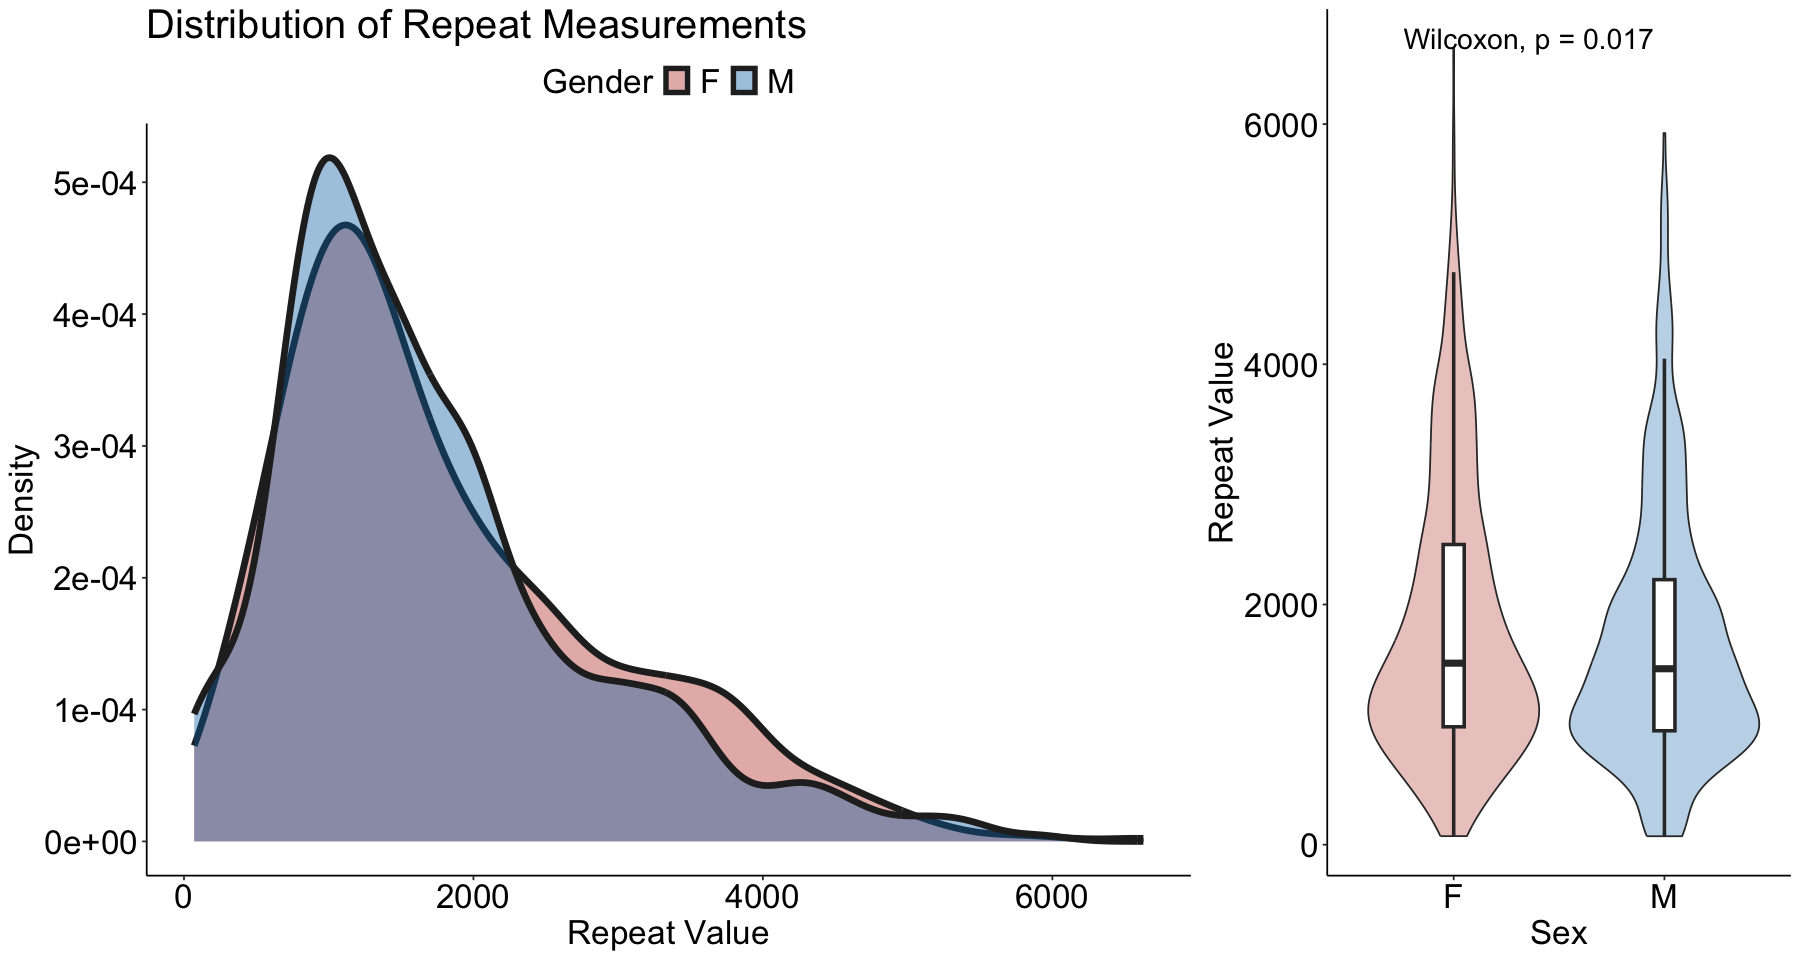

In [39]:
g1 <- ggplot(dd, aes(repeats, fill=Gender)) + 
geom_density(size=1.9, color="grey15")  + 
theme_classic() + gtheme(20) + 
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Density"
  ) + topleg + scale_fill_nejm(alpha=.4)

g2 <- ggplot(dd, aes(y=repeats, x=Gender)) + 
geom_violin(alpha=.3, aes(fill=Gender)) + 
geom_boxplot(outlier.shape = NA, width=.1, size=1, fill="white") +
#geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(20) + 
  labs(
    #title = "Distribution of Repeat Measurements",
    y = "Repeat Value",
    x = "Sex"
  ) + noleg + stat_compare_means(size=6) + scale_fill_nejm(alpha=.4)

options(repr.plot.width=15, repr.plot.height=8)
ggarrange(g1, g2, widths=c(2,1))

## Repeats x Age

In [44]:
head(dc,2)

Sample,Molecules_count,Mean,Median,SD,Mode,P90,Min,Max,Prop_gt500,⋯,Prop_gt2500,Prop_gt3000,Prop_gt3500,Prop_gt4000,Prop_gt4500,Prop_gt5000,Condition,AP,AO,Gender
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
125839,83,1880.4995983935746,1261.8166666666657,1300.1120468858946,2070.550000000008,3870.24,71.53333333333528,6579.449999999997,0.9879518072289156,⋯,0.21686746987951808,0.18072289156626506,0.14457831325301204,0.08433734939759036,0.07228915662650602,0.03614457831325301,FTD,65,63,F
128743,74,2933.663513513514,2785.2250000000013,1369.1855031114526,3099.25,4804.889999999999,131.8833333333338,5524.066666666666,0.9594594594594594,⋯,0.5675675675675675,0.44594594594594594,0.33783783783783783,0.2702702702702703,0.14864864864864866,0.06756756756756757,FTD,76,66,M


In [45]:
summary(dc$AP)
dd$group_age <- "64-"
dd$group_age[which(dd$AP >= 64)] <- "64+"
dd$group_age <- factor(dd$group_age, levels=c("64-","64+"))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  36.00   56.00   65.00   64.22   72.25   89.00 

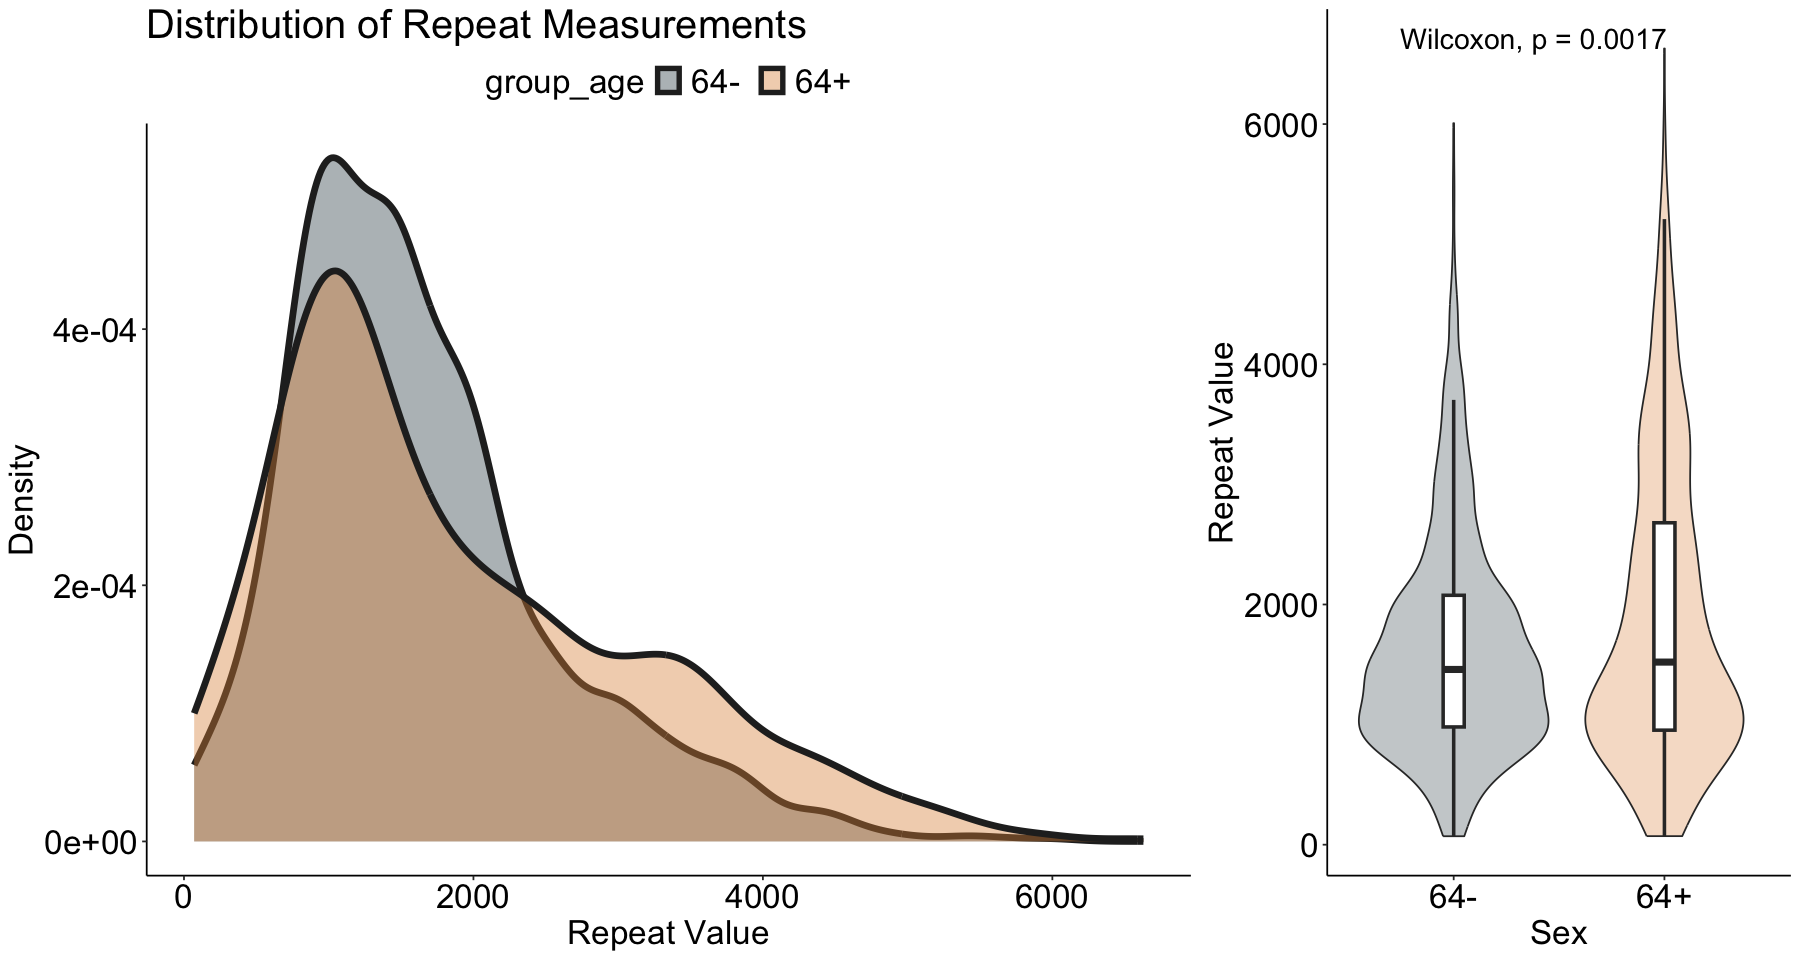

In [46]:
options(repr.plot.width=10, repr.plot.height=8)

g1 <- ggplot(dd, aes(repeats, fill=group_age)) + 
geom_density(size=1.9, color="grey15")  + 
theme_classic() + gtheme(20) + 
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Density"
  ) + topleg + scale_fill_jama(alpha=.4)

g2 <- ggplot(dd, aes(y=repeats, x=group_age)) + 
geom_violin(alpha=.3, aes(fill=group_age)) + 
geom_boxplot(outlier.shape = NA, width=.1, size=1, fill="white") +
theme_classic() + gtheme(20) + 
  labs(
    y = "Repeat Value",
    x = "Sex"
  ) + noleg + stat_compare_means(size=6) + scale_fill_jama(alpha=.4)

options(repr.plot.width=15, repr.plot.height=8)
ggarrange(g1, g2, widths=c(2,1))

## Repeats x Condition

In [47]:
table(dc$Condition)


ALS FTD 
 17  23 

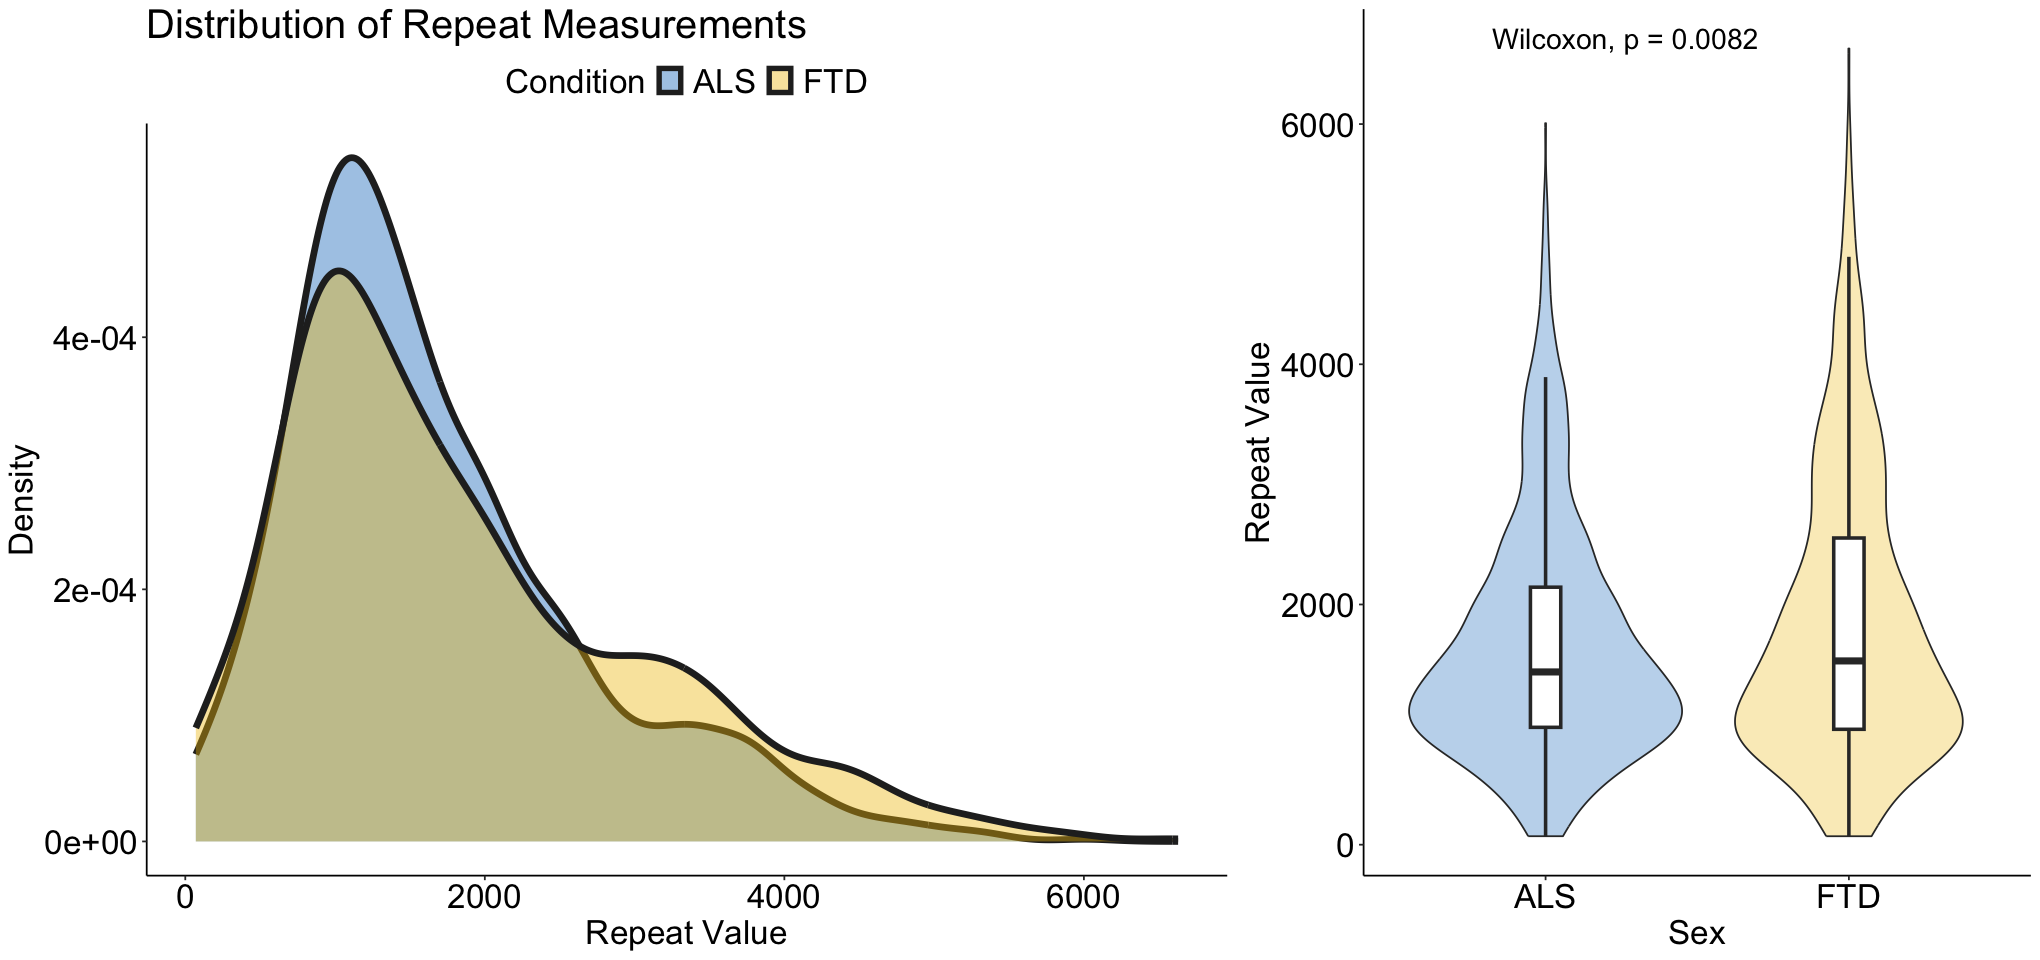

In [48]:
g1 <- ggplot(dd, aes(repeats, fill=Condition)) + 
geom_density(size=1.9, color="grey15")  + 
theme_classic() + gtheme(20) + 
  labs(
    title = "Distribution of Repeat Measurements",
    x = "Repeat Value",
    y = "Density"
  ) + topleg + scale_fill_jco(alpha=.4)

g2 <- ggplot(dd, aes(y=repeats, x=Condition)) + 
geom_violin(alpha=.3, aes(fill=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.1, size=1, fill="white") +
theme_classic() + gtheme(20) + 
  labs(
    y = "Repeat Value",
    x = "Sex"
  ) + noleg + stat_compare_means(size=6) + scale_fill_jco(alpha=.4)

options(repr.plot.width=17, repr.plot.height=8)
ggarrange(g1, g2, widths=c(2,1.3))

# Size Region Enrichment 

`geom_smooth()` using formula = 'y ~ x'


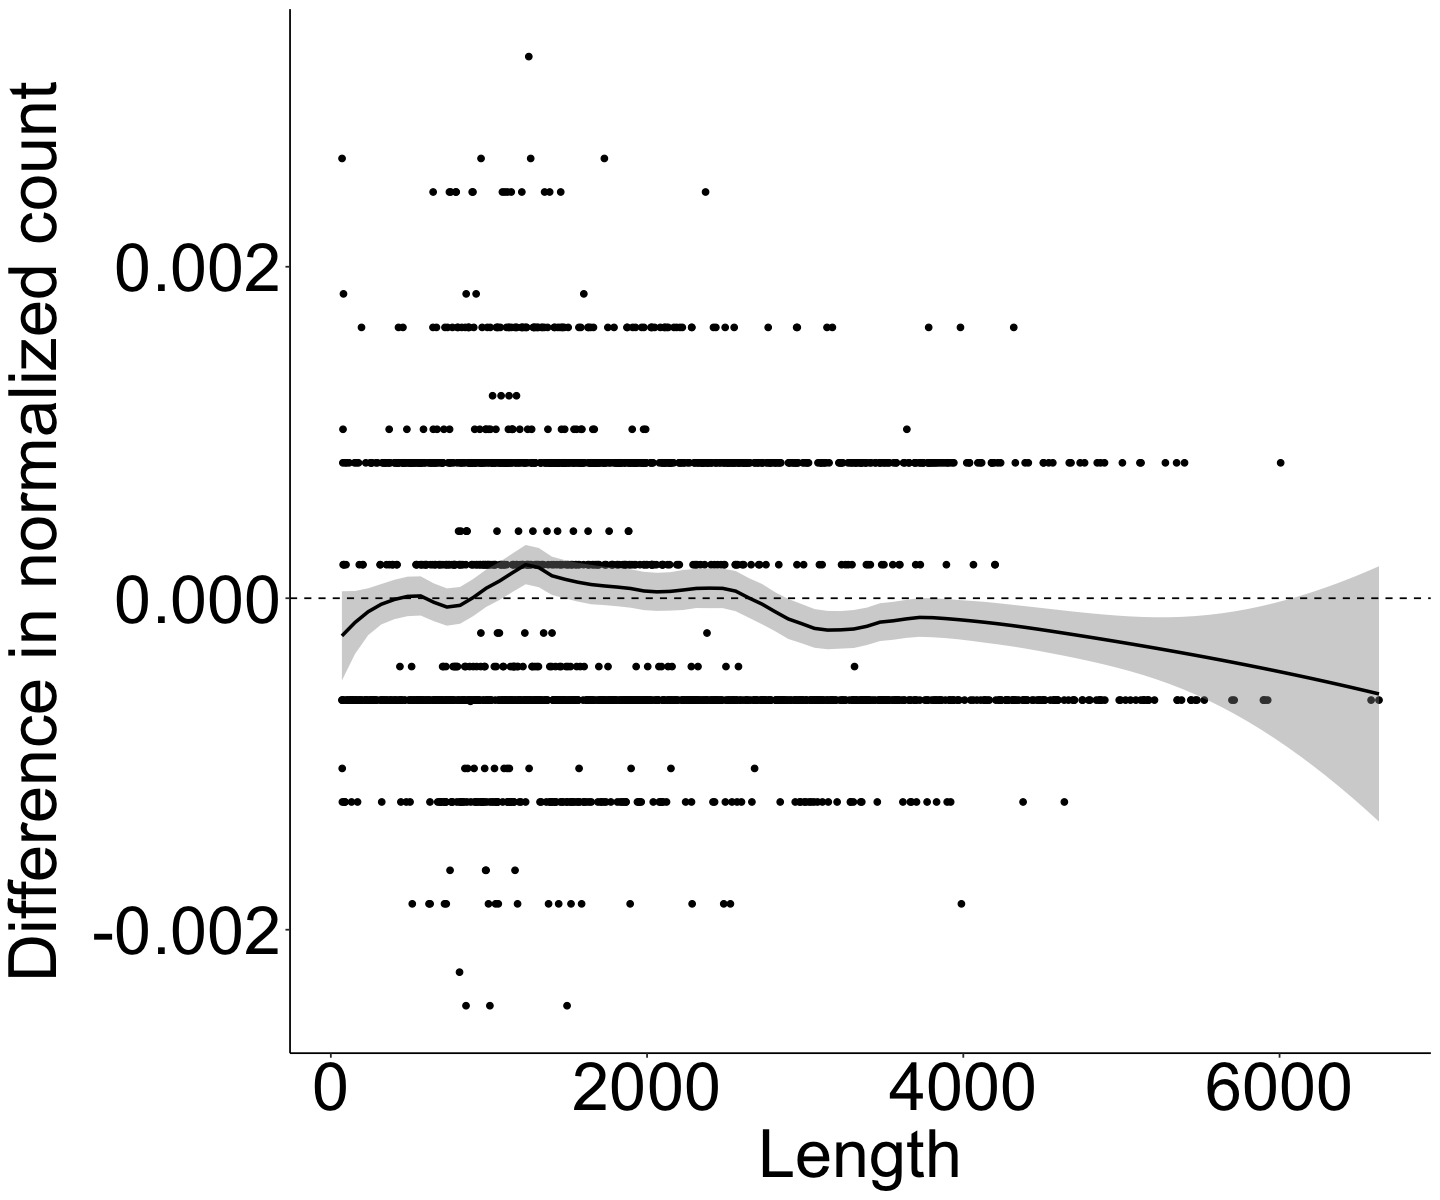

In [51]:
# Calculate Counts and Props 
dregions <- dd %>% 
group_by(Condition, round(repeats), .drop = FALSE) %>% summarise(n=n(), .groups = "drop_last") %>%
mutate(prop=n / sum(n)) %>%
pivot_wider(names_from=Condition, values_from=c(n,prop)) %>%
replace(is.na(.), 0) %>% rename(Repeat = "round(repeats)")
dregions$diff_ALS_FTD <- dregions$prop_ALS -  dregions$prop_FTD

options(repr.plot.width=12,repr.plot.height=10)

ggplot(dregions, aes(x = Repeat, y=diff_ALS_FTD)) +
  geom_point(size=1.5) +
  geom_smooth(method="loess", span=0.3, color="black", level=0.95, fill="grey55") + 
  geom_hline(yintercept=0, linetype="dashed", size=0.5) + 
  theme_classic() + gtheme(40) + 
  xlab("Length") +
  ylab("Difference in normalized count")

## With binning

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”


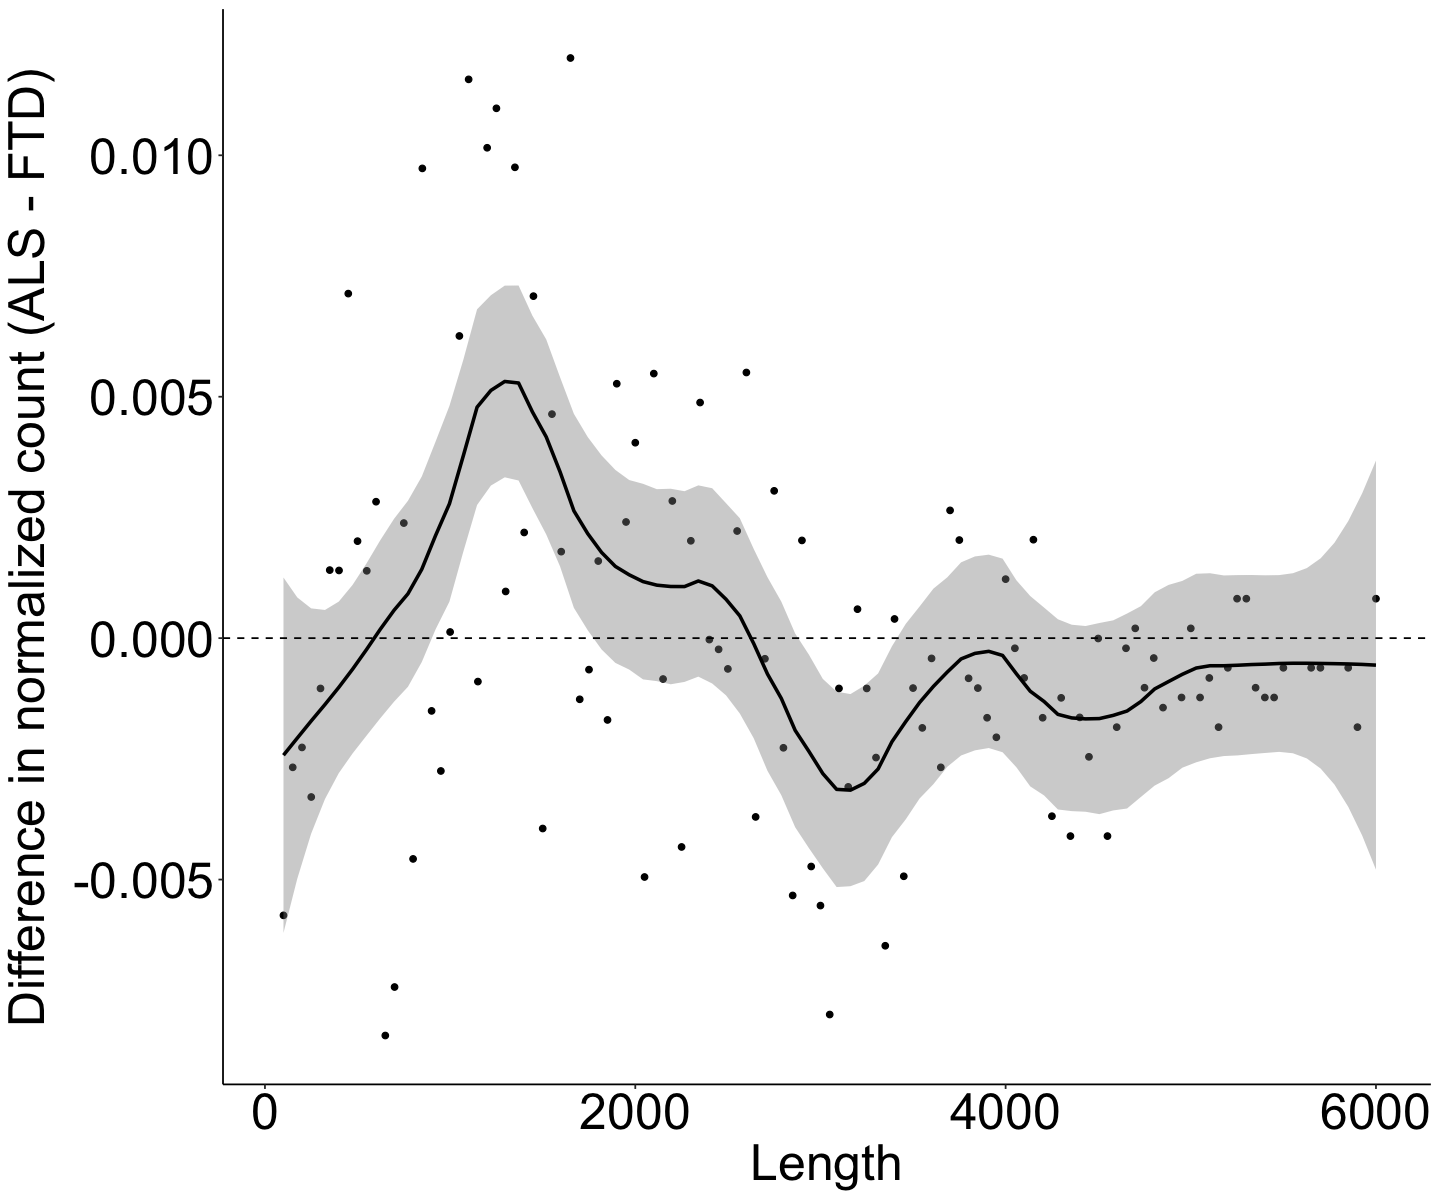

In [52]:
bin_size <- 50

dd_binned <- dd %>%
  mutate(
    repeat_bin = floor(repeats / bin_size) * bin_size
  )

dregions <- dd_binned %>% 
group_by(Condition, repeat_bin, .drop = FALSE) %>% summarise(n=n(), .groups = "drop_last") %>%
mutate(prop=n / sum(n)) %>%
pivot_wider(names_from=Condition, values_from=c(n,prop)) %>%
replace(is.na(.), 0)
dregions$diff_ALS_FTD <- dregions$prop_ALS -  dregions$prop_FTD

options(repr.plot.width=12,repr.plot.height=10)

ggplot(dregions, aes(x = repeat_bin, y=diff_ALS_FTD)) +
  geom_point(size=1.5) +
  geom_smooth(method="loess", span=0.3, color="black", level=0.95, fill="grey55") + 
  geom_hline(yintercept=0, linetype="dashed", size=0.5) + 
  theme_classic() + gtheme(30) + 
  xlab("Length") +
  ylab("Difference in normalized count (ALS - FTD)") + 
  scale_x_continuous(limits=c(70,6000))
#geom_vline()
#, breaks=c(100, 150, 200, 250, 300), guide = guide_axis(n.dodge = 1))

## for age < 64y

In [54]:
head(dd)

Sample,repeats,Condition,AP,AO,Gender,group_age
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<fct>
125839,2070.550,FTD,65,63,F,64+
125839,5091.083,FTD,65,63,F,64+
125839,1183.633,FTD,65,63,F,64+
125839,2610.517,FTD,65,63,F,64+
125839,621.100,FTD,65,63,F,64+
125839,1308.817,FTD,65,63,F,64+


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range (`geom_point()`).”


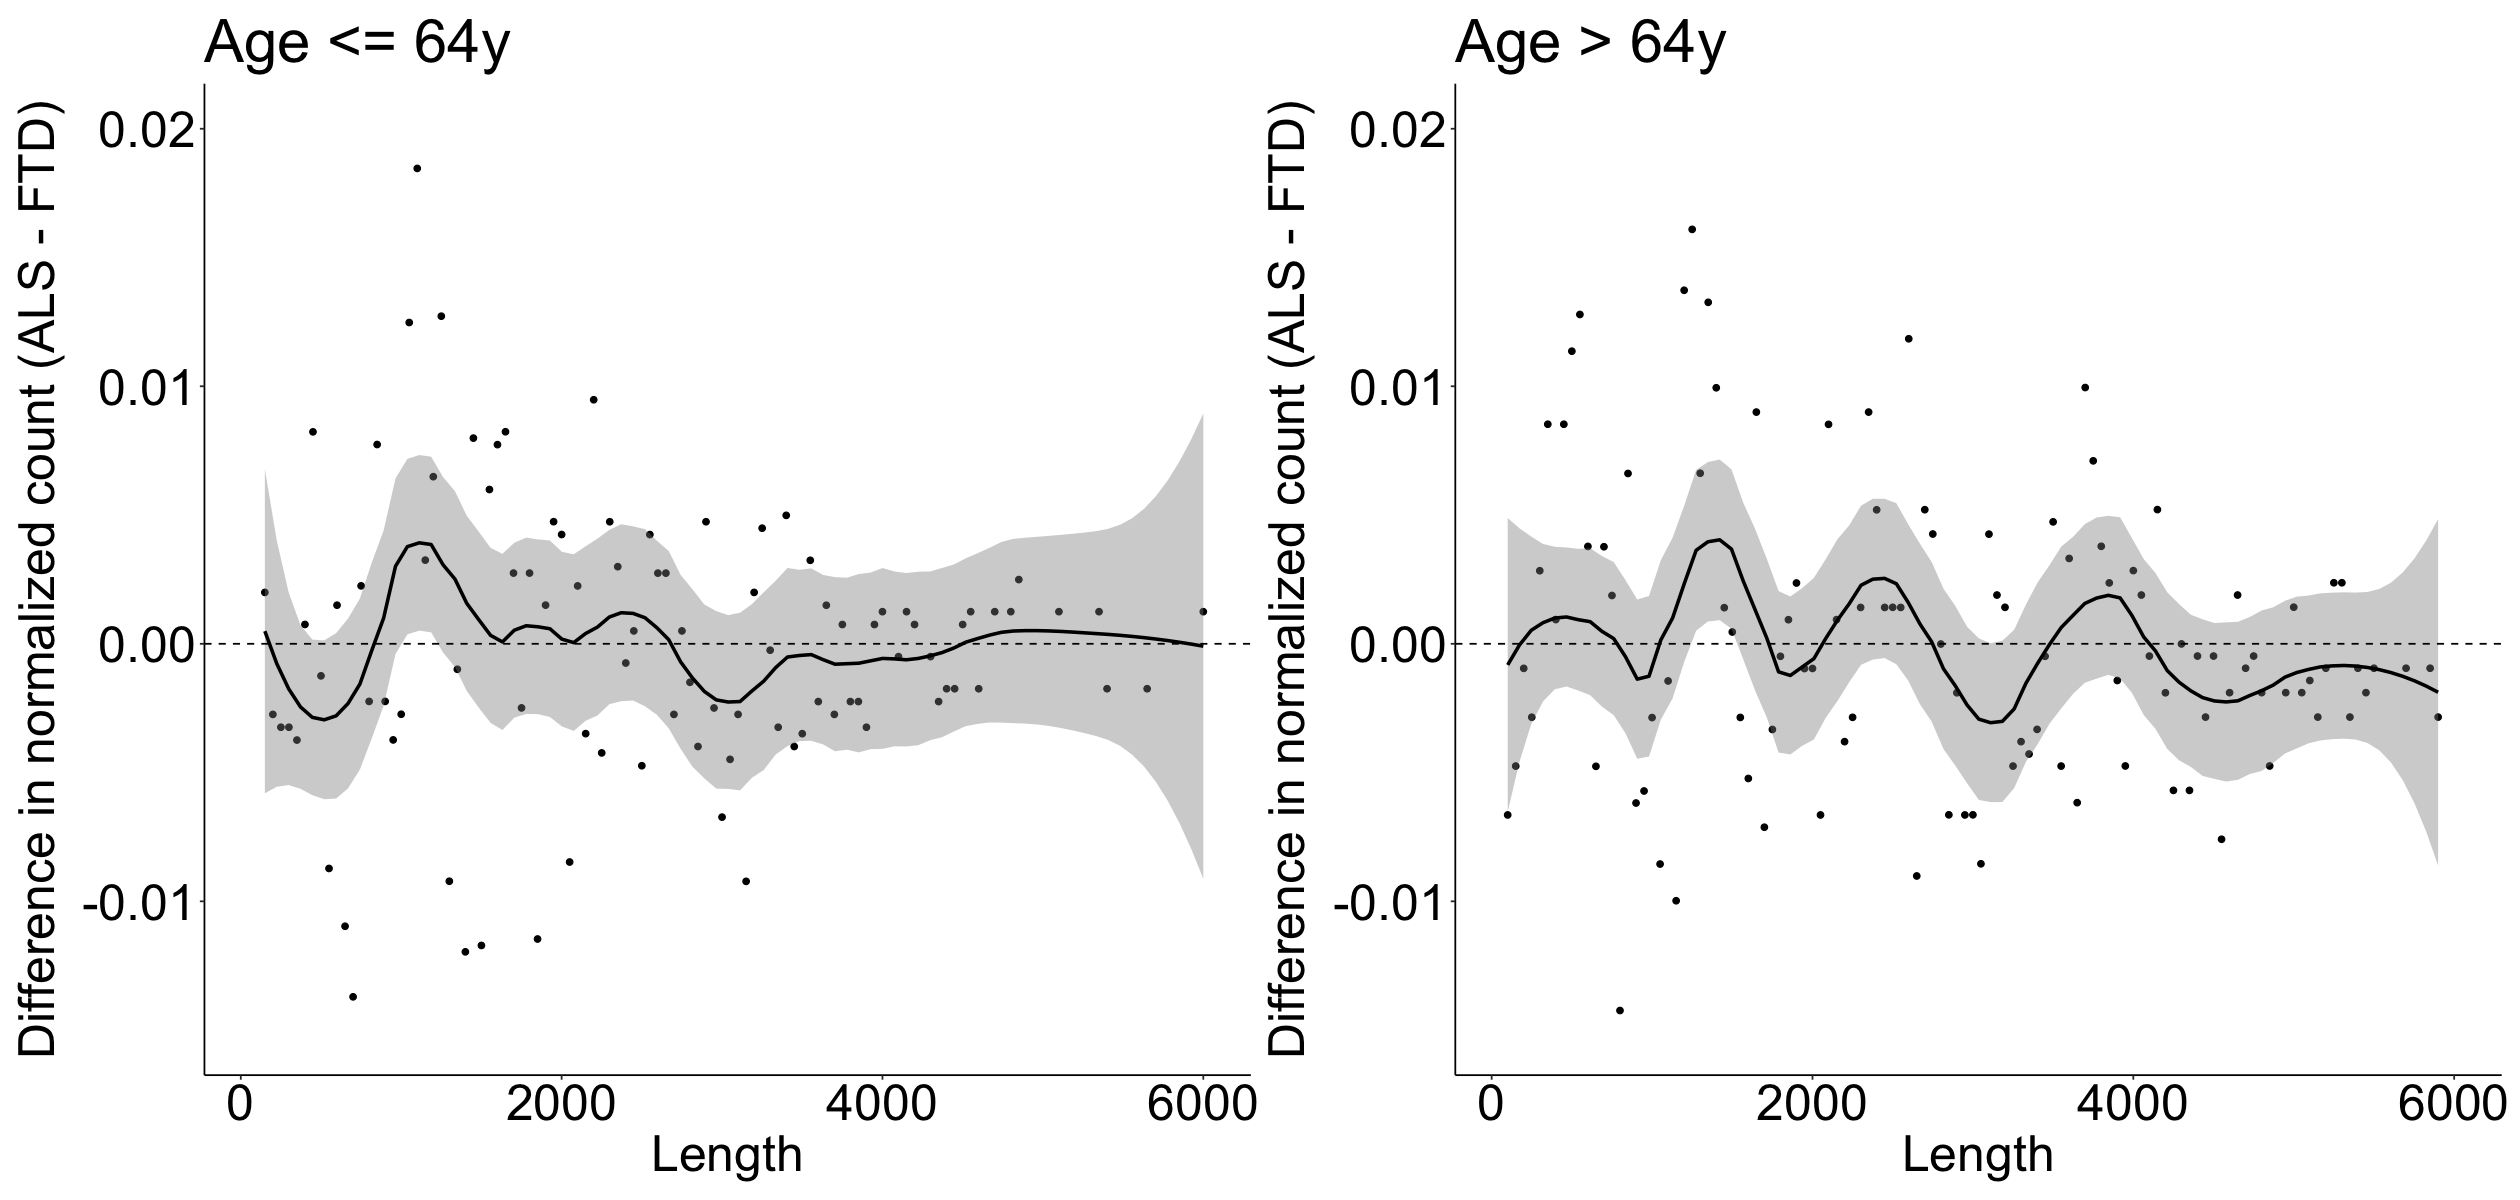

In [69]:
bin_size <- 50

dd_binned1 <- dd %>% filter(AP<=64) %>%
  mutate(
    repeat_bin = floor(repeats / bin_size) * bin_size
  )

dregions1 <- dd_binned1 %>% 
group_by(Condition, repeat_bin, .drop = FALSE) %>% summarise(n=n(), .groups = "drop_last") %>%
mutate(prop=n / sum(n)) %>%
pivot_wider(names_from=Condition, values_from=c(n,prop)) %>%
replace(is.na(.), 0)
dregions1$diff_ALS_FTD <- dregions1$prop_ALS -  dregions1$prop_FTD

dd_binned2 <- dd %>% filter(AP>64) %>%
  mutate(
    repeat_bin = floor(repeats / bin_size) * bin_size
  )

dregions2 <- dd_binned2 %>% 
group_by(Condition, repeat_bin, .drop = FALSE) %>% summarise(n=n(), .groups = "drop_last") %>%
mutate(prop=n / sum(n)) %>%
pivot_wider(names_from=Condition, values_from=c(n,prop)) %>%
replace(is.na(.), 0)
dregions2$diff_ALS_FTD <- dregions2$prop_ALS -  dregions2$prop_FTD

options(repr.plot.width=21, repr.plot.height=10)

g1 <- ggplot(dregions1, aes(x = repeat_bin, y=diff_ALS_FTD)) +
  geom_point(size=1.5) +
  geom_smooth(method="loess", span=0.3, color="black", level=0.95, fill="grey55") + 
  geom_hline(yintercept=0, linetype="dashed", size=0.5) + 
  theme_classic() + gtheme(30) + 
  xlab("Length") +
  ylab("Difference in normalized count (ALS - FTD)") + 
  scale_x_continuous(limits=c(70,6000)) + ylim(c(-0.015,0.02)) + ggtitle("Age <= 64y")

g2 <- ggplot(dregions2, aes(x = repeat_bin, y=diff_ALS_FTD)) +
  geom_point(size=1.5) +
  geom_smooth(method="loess", span=0.3, color="black", level=0.95, fill="grey55") + 
  geom_hline(yintercept=0, linetype="dashed", size=0.5) + 
  theme_classic() + gtheme(30) + 
  xlab("Length") +
  ylab("Difference in normalized count (ALS - FTD)") + 
  scale_x_continuous(limits=c(70,6000)) + ylim(c(-0.015,0.02)) + ggtitle("Age > 64y")

g1 + g2

In [35]:
#seq(100,6000,50) %in% sort(unique(dd_binned$repeat_bin))

# Patient-level metrics

In [70]:
head(dd,2)

Sample,repeats,Condition,AP,AO,Gender,group_age
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<fct>
125839,2070.550,FTD,65,63,F,64+
125839,5091.083,FTD,65,63,F,64+


In [71]:
head(dc,2)

Sample,Molecules_count,Mean,Median,SD,Mode,P90,Min,Max,Prop_gt500,⋯,Prop_gt2500,Prop_gt3000,Prop_gt3500,Prop_gt4000,Prop_gt4500,Prop_gt5000,Condition,AP,AO,Gender
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
125839,83,1880.4995983935746,1261.8166666666657,1300.1120468858946,2070.550000000008,3870.24,71.53333333333528,6579.449999999997,0.9879518072289156,⋯,0.21686746987951808,0.18072289156626506,0.14457831325301204,0.08433734939759036,0.07228915662650602,0.03614457831325301,FTD,65,63,F
128743,74,2933.663513513514,2785.2250000000013,1369.1855031114526,3099.25,4804.889999999999,131.8833333333338,5524.066666666666,0.9594594594594594,⋯,0.5675675675675675,0.44594594594594594,0.33783783783783783,0.2702702702702703,0.14864864864864866,0.06756756756756757,FTD,76,66,M


In [72]:
df <- dd %>%
group_by(Sample, AP, AO, Gender, group_age, Condition) %>%
summarise(
    n_molecules = n(),
    mean = mean(repeats),
    median = median(repeats),
    min = min(repeats),
    max = max(repeats),
    sd = sd(repeats),
    n_2000 = sum(repeats < 2000),
    n_3000 = sum(repeats < 3000),
    n_4000 = sum(repeats < 4000),
    m_2000 = sum(repeats > 2000),
    m_3000 = sum(repeats > 3000),
    m_4000 = sum(repeats > 4000)
)
df$prop_2000 <- df$n_2000 / df$n_molecules
df$prop_3000 <- df$n_3000 / df$n_molecules
df$prop_4000 <- df$n_4000 / df$n_molecules
df$mprop_2000 <- df$m_2000 / df$n_molecules
df$mprop_3000 <- df$m_3000 / df$n_molecules
df$mprop_4000 <- df$m_4000 / df$n_molecules

df$Condition <- gsub("Presymptomatic","Pre",df$Condition)

head(df,3)

`summarise()` has grouped output by 'Sample', 'AP', 'AO', 'Gender', 'group_age'. You can override
using the `.groups` argument.


Sample,AP,AO,Gender,group_age,Condition,n_molecules,mean,median,min,⋯,n_4000,m_2000,m_3000,m_4000,prop_2000,prop_3000,prop_4000,mprop_2000,mprop_3000,mprop_4000
<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
125839,65,63,F,64+,FTD,83,1880.500,1261.817,71.53333,⋯,76,25,15,7,0.6987952,0.8192771,0.9156627,0.3012048,0.1807229,0.08433735
128743,76,66,M,64+,FTD,74,2933.664,2785.225,131.88333,⋯,54,54,33,20,0.2702703,0.5540541,0.7297297,0.7297297,0.4459459,0.27027027
131123,53,42,F,64-,FTD,65,2590.527,2562.800,569.20000,⋯,59,44,26,6,0.3230769,0.6000000,0.9076923,0.6769231,0.4000000,0.09230769


In [73]:
summary(df$n_molecules)
summary(dc$Molecules_count)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  48.00   62.50   72.00   71.28   81.25   92.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  48.00   62.50   72.00   71.28   81.25   92.00 

In [74]:
summary(df$prop_4000)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7297  0.9261  0.9765  0.9501  1.0000  1.0000 

# Compare patient-level ALS vs. FTD

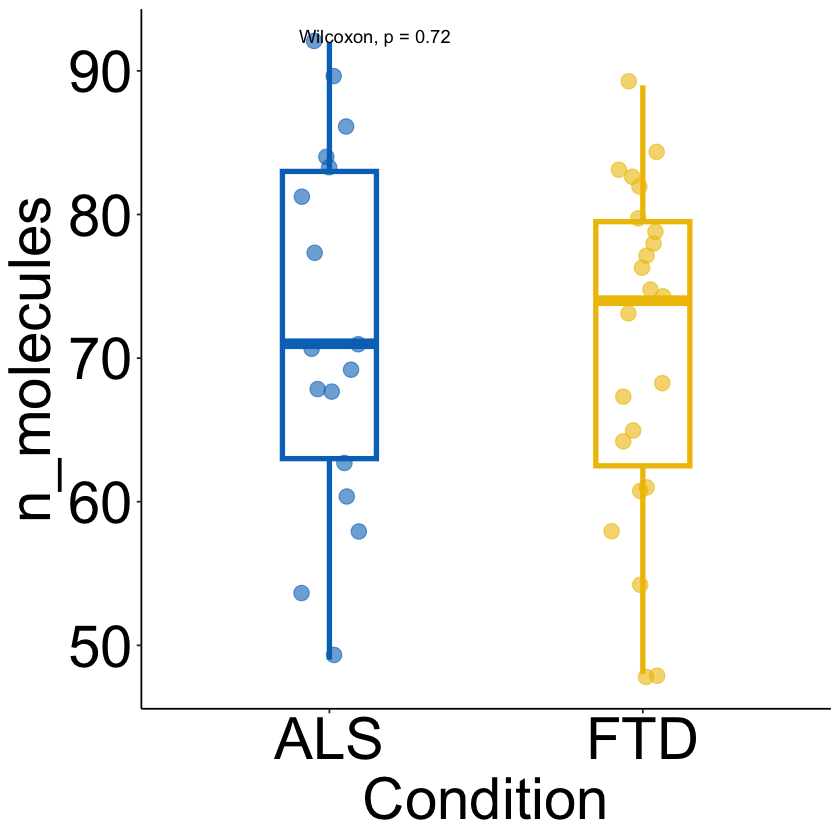

In [75]:
options(repr.plot.width=7, repr.plot.height=7)

ggplot(df, aes(x=Condition, y=n_molecules, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

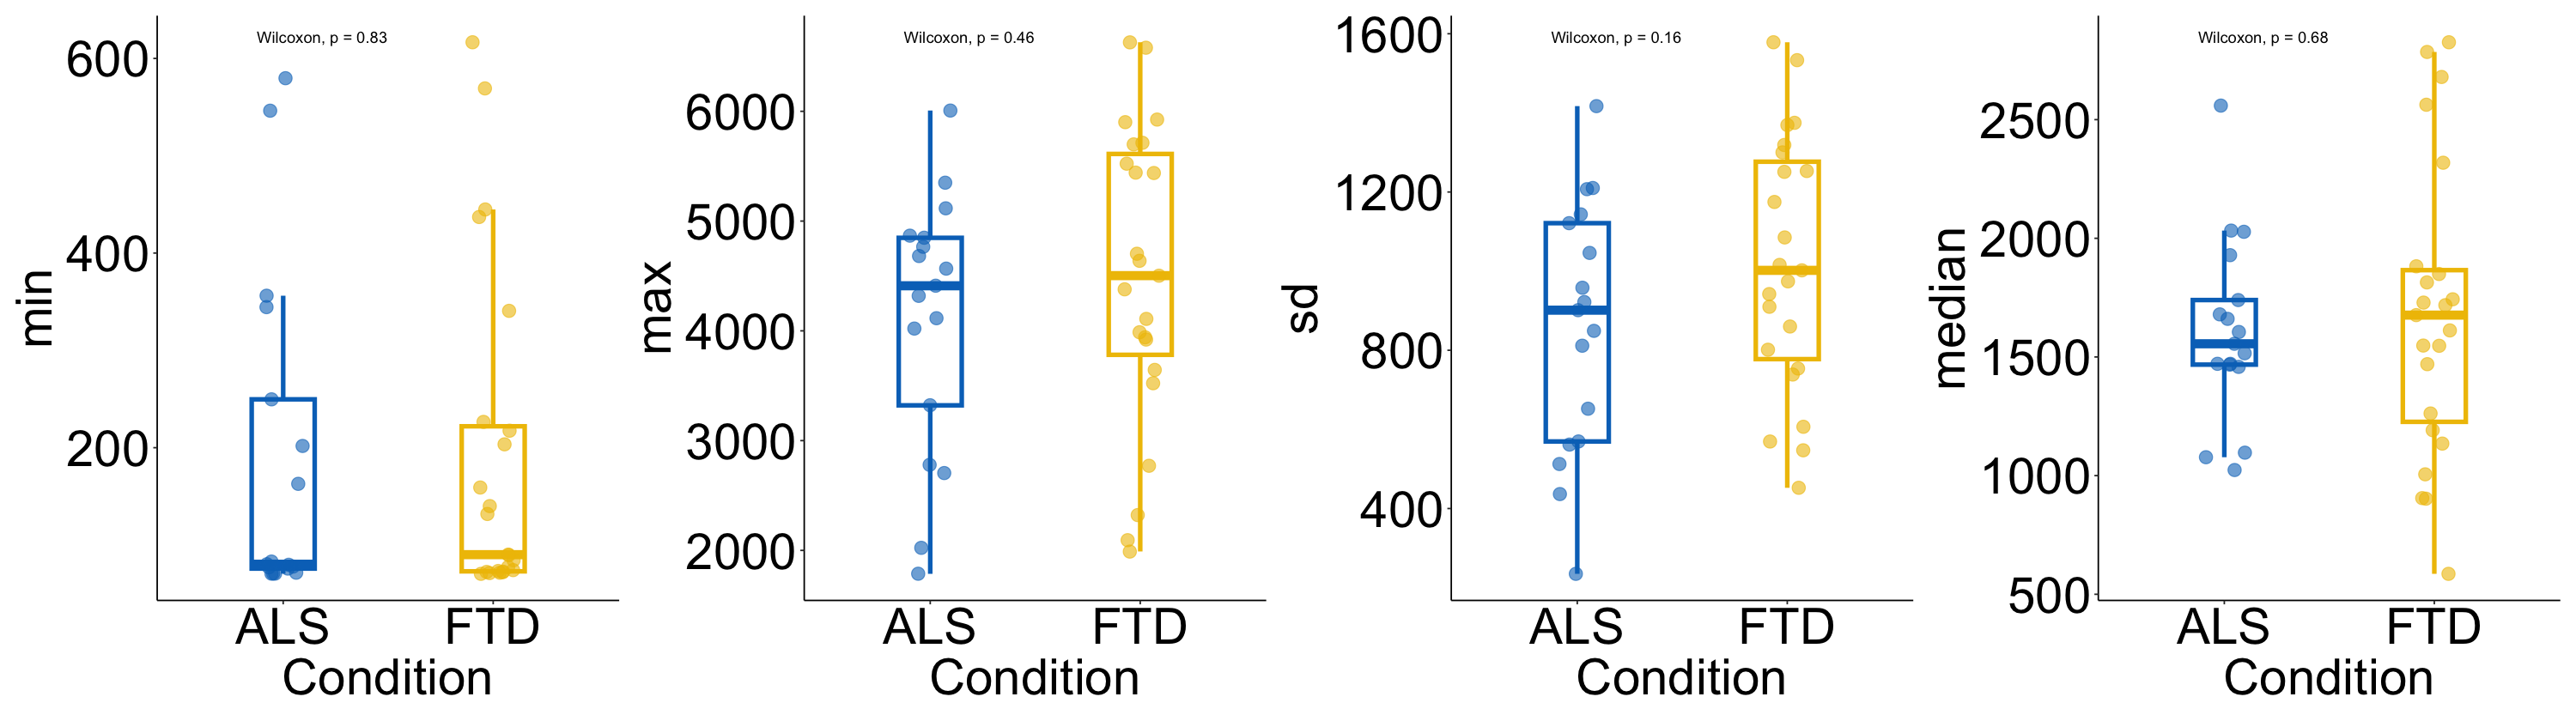

In [76]:
gmin <- ggplot(df, aes(x=Condition, y=min, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

gmax <- ggplot(df, aes(x=Condition, y=max, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

gsd <- ggplot(df, aes(x=Condition, y=sd, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

gmedian <- ggplot(df, aes(x=Condition, y=median, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

options(repr.plot.width=25, repr.plot.height=7)
gmin + gmax + gsd + gmedian + plot_layout(ncol = 4)

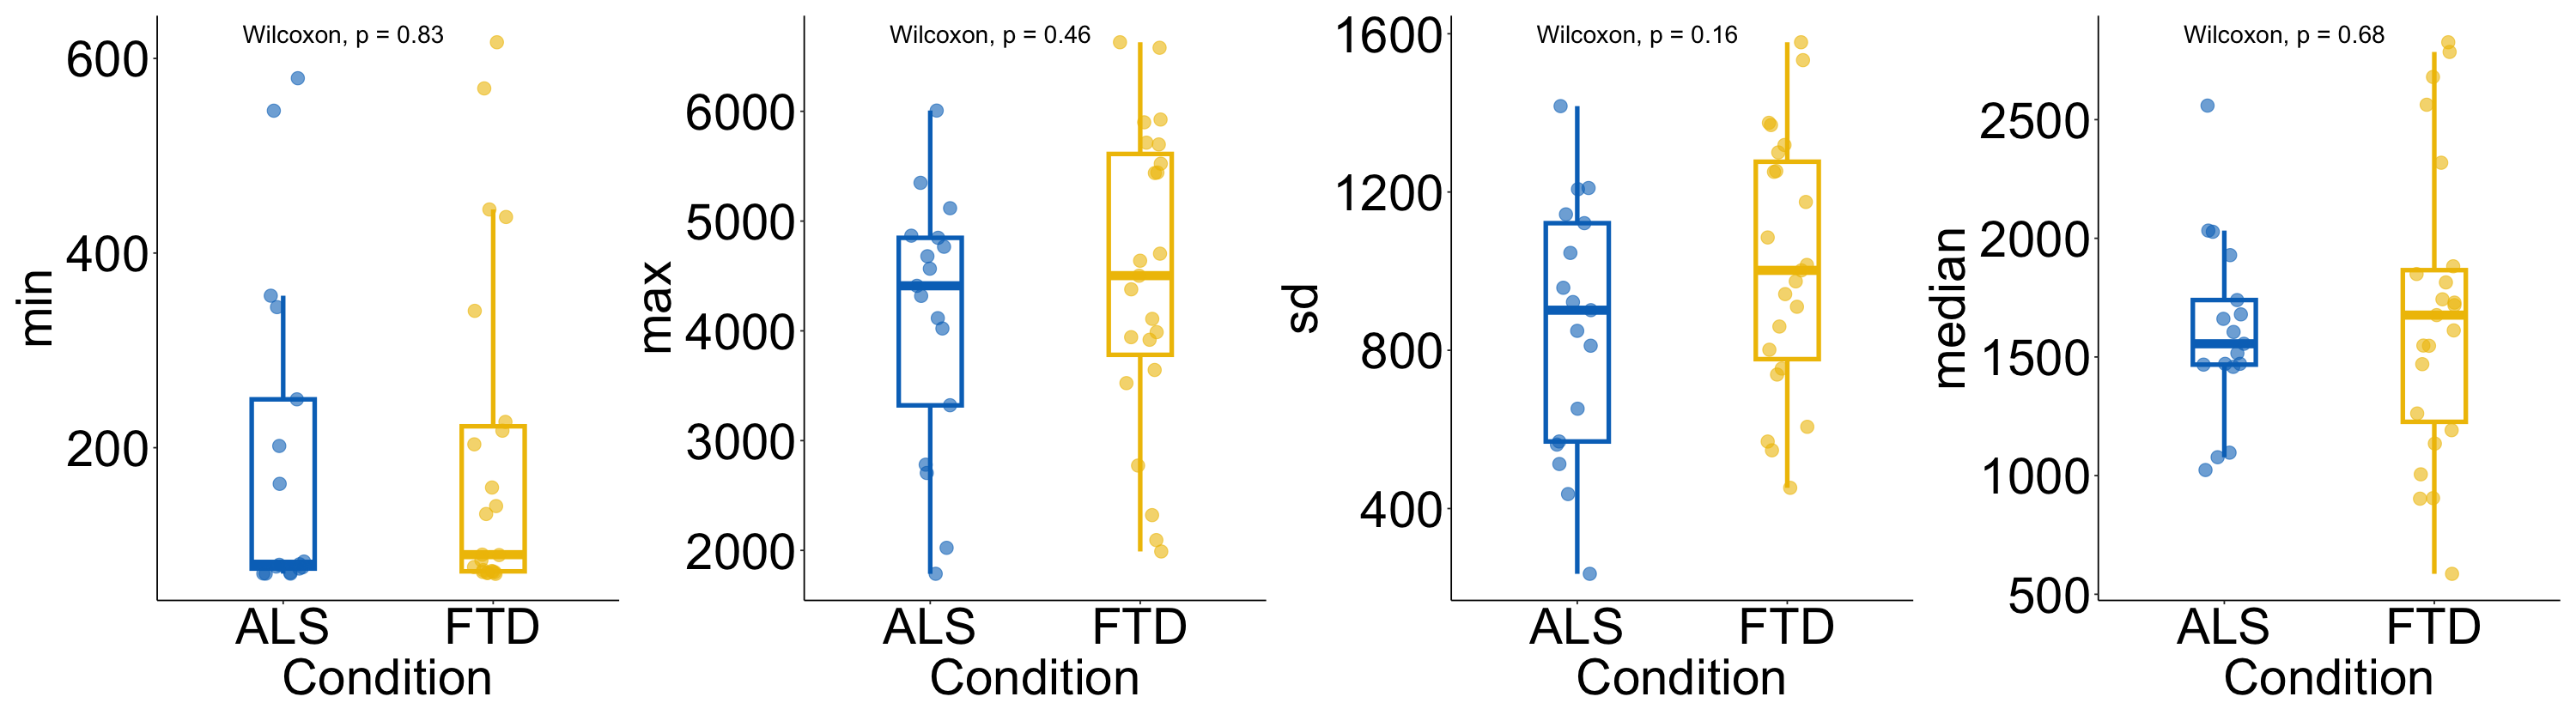

In [77]:
dff <- df %>% filter(Condition %in% c("ALS","FTD"))

gmin <- ggplot(dff, aes(x=Condition, y=min, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gmax <- ggplot(dff, aes(x=Condition, y=max, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gsd <- ggplot(dff, aes(x=Condition, y=sd, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gmedian <- ggplot(dff, aes(x=Condition, y=median, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

options(repr.plot.width=25, repr.plot.height=7)
gmin + gmax + gsd + gmedian + plot_layout(ncol = 4)

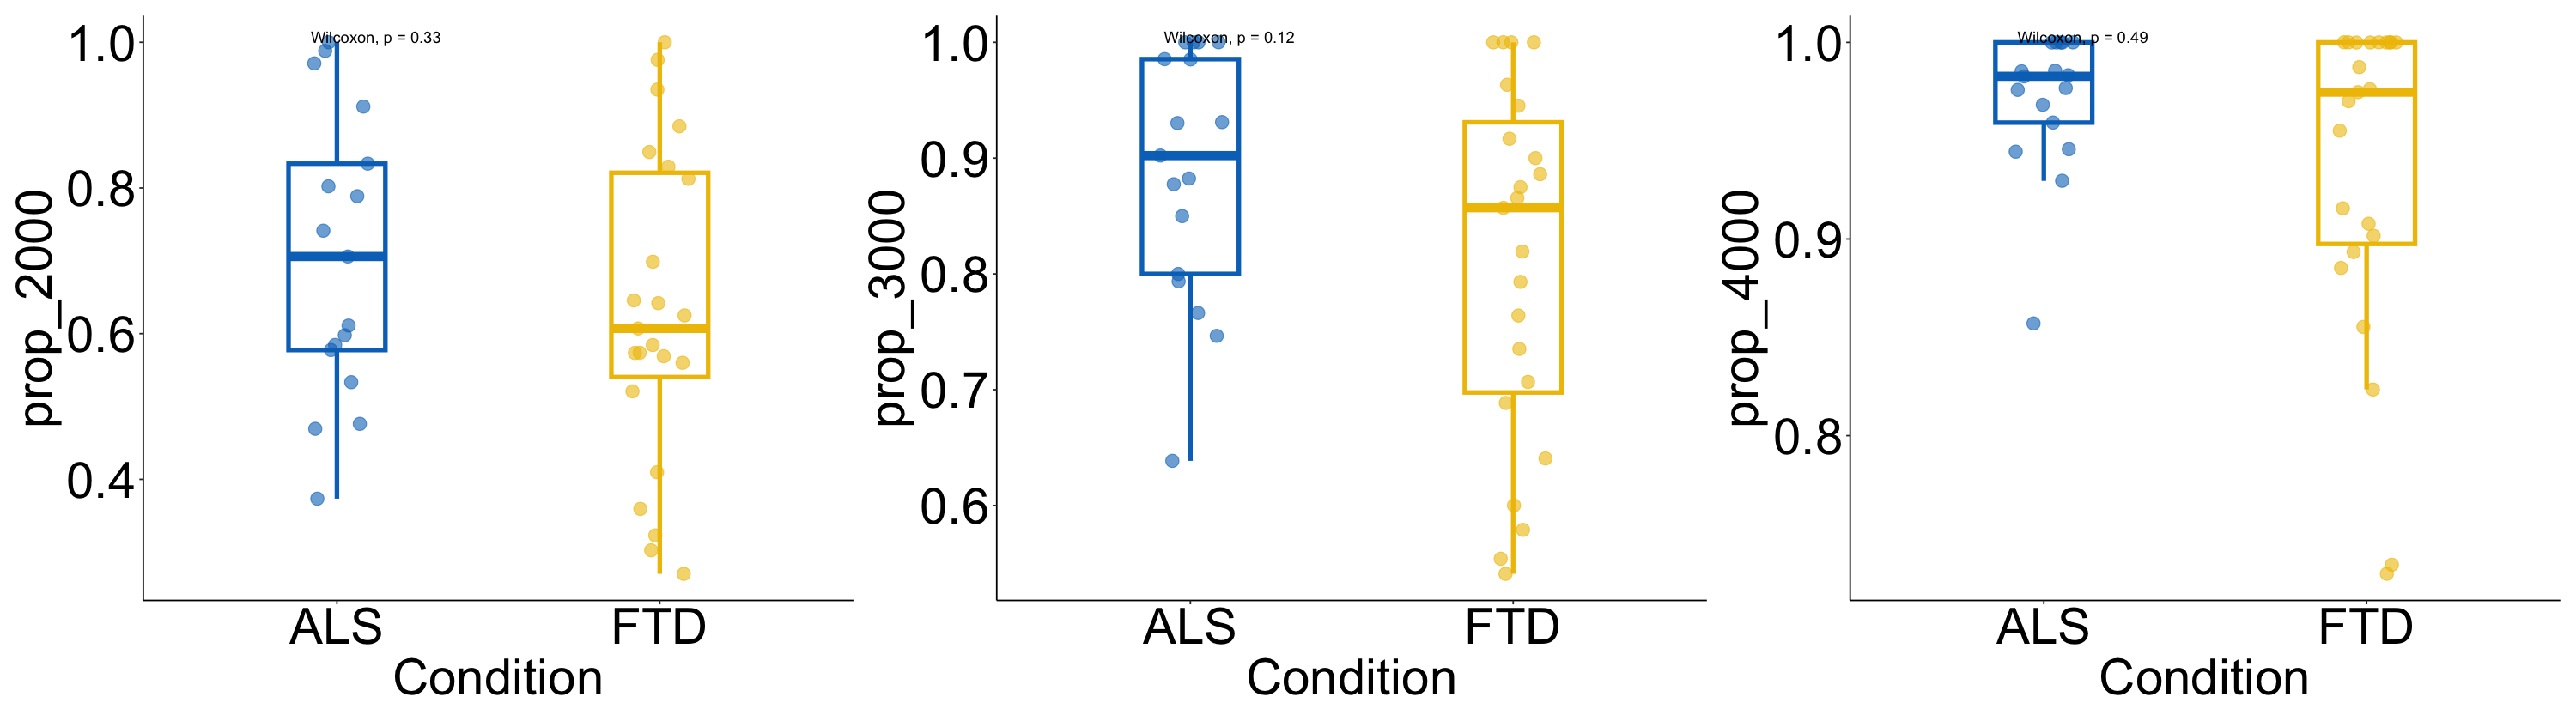

In [78]:
gprop_2000 <- ggplot(df, aes(x=Condition, y=prop_2000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

gprop_3000 <- ggplot(df, aes(x=Condition, y=prop_3000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

gprop_4000 <- ggplot(df, aes(x=Condition, y=prop_4000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means() + 
noleg + scale_colour_jco()

options(repr.plot.width=25, repr.plot.height=7)
gprop_2000 + gprop_3000 + gprop_4000 + plot_layout(ncol = 3)

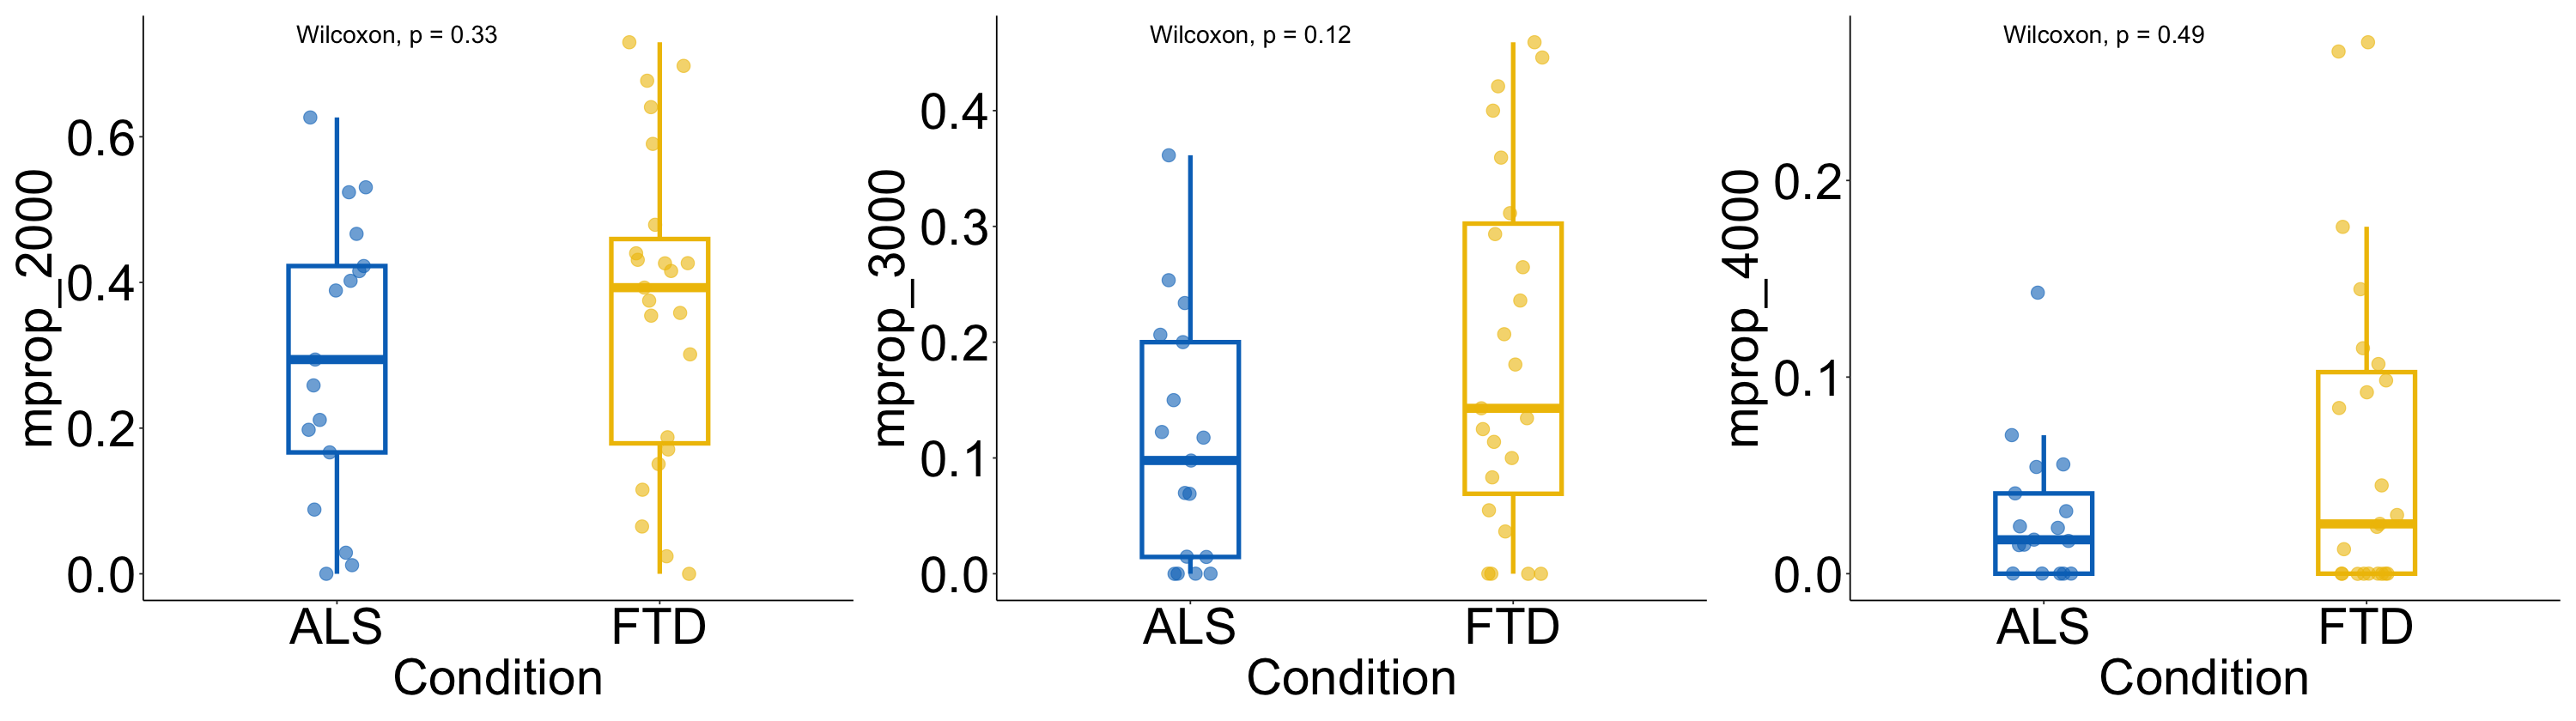

In [79]:
gprop_2000 <- ggplot(df, aes(x=Condition, y=mprop_2000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gprop_3000 <- ggplot(df, aes(x=Condition, y=mprop_3000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gprop_4000 <- ggplot(df, aes(x=Condition, y=mprop_4000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

options(repr.plot.width=25, repr.plot.height=7)
gprop_2000 + gprop_3000 + gprop_4000 + plot_layout(ncol = 3)

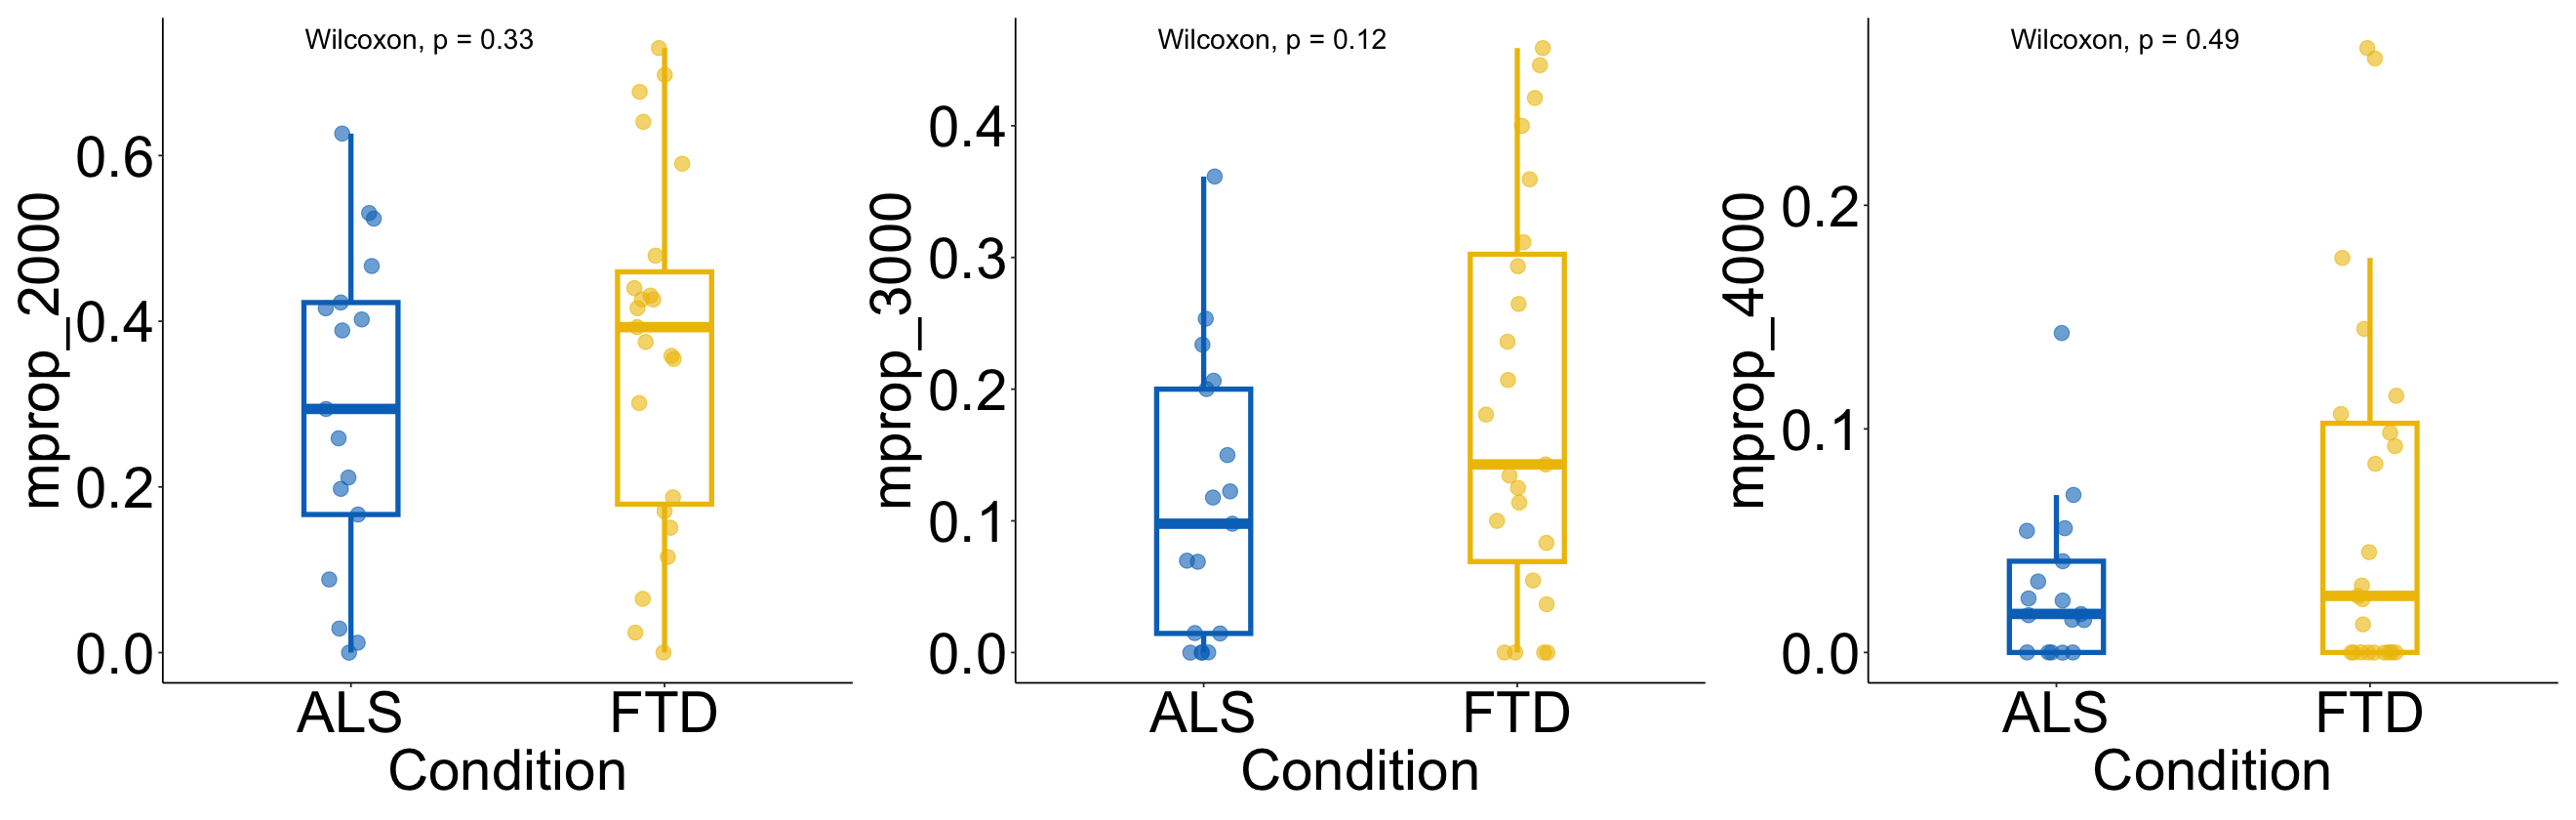

In [80]:
gprop_2000 <- ggplot(dff, aes(x=Condition, y=mprop_2000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gprop_3000 <- ggplot(dff, aes(x=Condition, y=mprop_3000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

gprop_4000 <- ggplot(dff, aes(x=Condition, y=mprop_4000, colour=Condition)) + 
geom_boxplot(outlier.shape = NA, width=.3, size=1.5) + 
geom_jitter(size=4, width = .1, alpha=.6) + 
theme_classic() + gtheme(35) + stat_compare_means(size=6) + 
noleg + scale_colour_jco()

options(repr.plot.width=22, repr.plot.height=7)
gprop_2000 + gprop_3000 + gprop_4000 + plot_layout(ncol = 3)

# Predictive Model for Repeats Length

In [81]:
head(dd,3)

Sample,repeats,Condition,AP,AO,Gender,group_age
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<fct>
125839,2070.550,FTD,65,63,F,64+
125839,5091.083,FTD,65,63,F,64+
125839,1183.633,FTD,65,63,F,64+


[1] 2851    7


Call:  glm(formula = repeats ~ Age10 + Gender + Condition, family = "gaussian", 
    data = tmp)

Coefficients:
 (Intercept)         Age10       GenderM  ConditionFTD  
     1460.82         44.44       -123.90        165.45  

Degrees of Freedom: 2850 Total (i.e. Null);  2847 Residual
Null Deviance:	    3.591e+09 
Residual Deviance: 3.553e+09 	AIC: 48120

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
“Unable to resize forest panel to be smaller than its heading; consider a smaller text size”


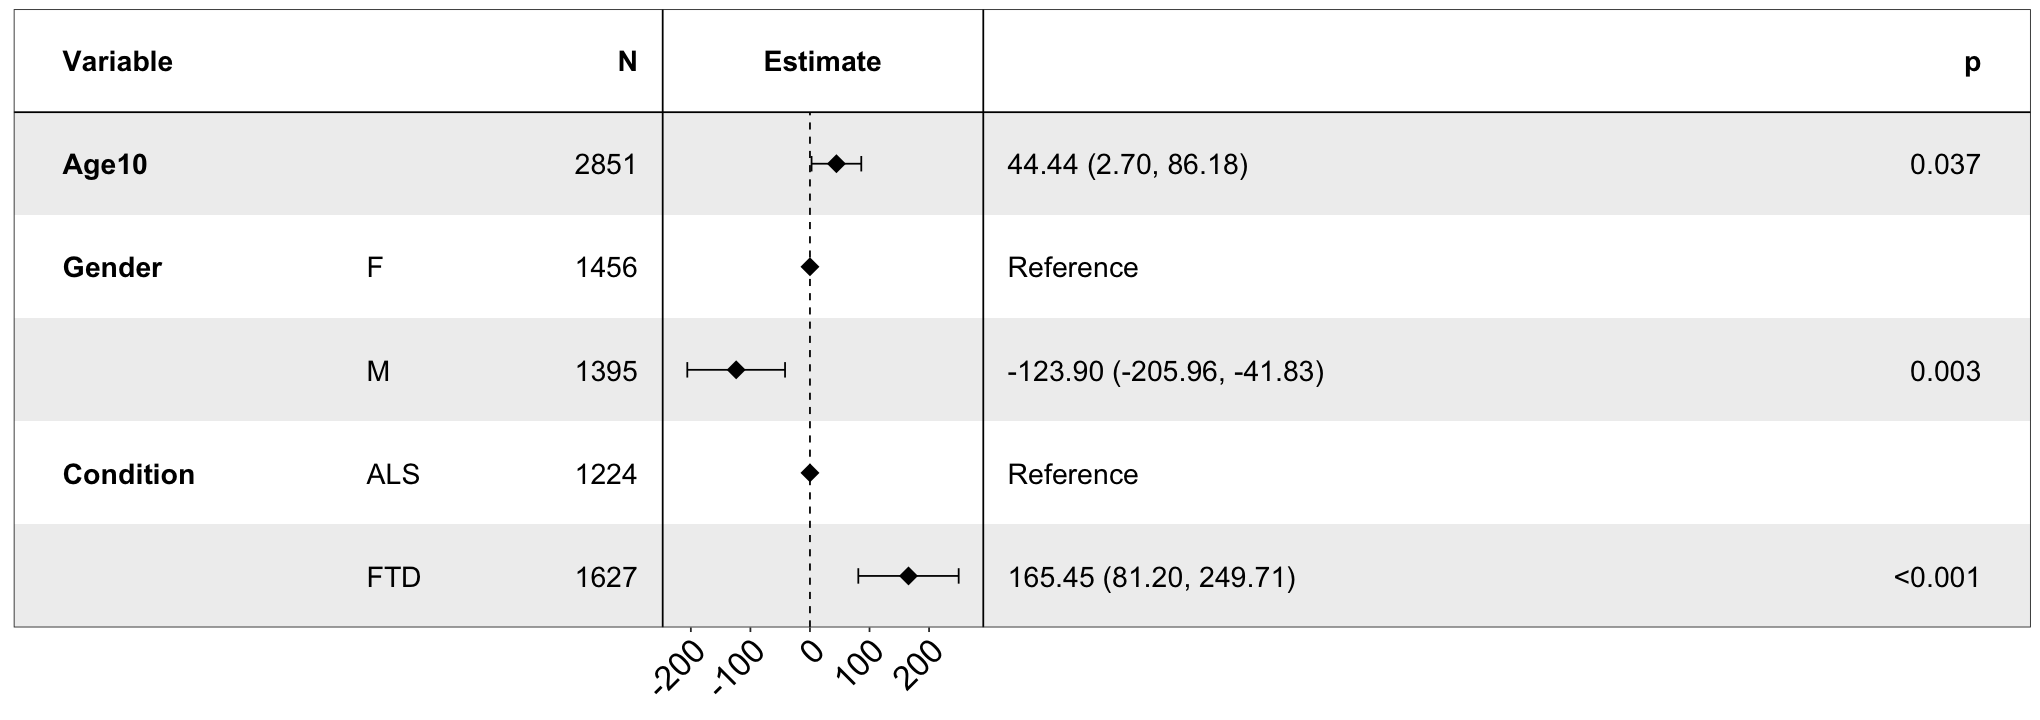

In [82]:
tmp <- dd
dim(tmp)
tmp$Age10 <- tmp$AP/10
reso <- glm(formula = repeats ~  Age10 + Gender + Condition, family="gaussian", data=tmp)

reso

library(forestmodel)

options(repr.plot.width=17, repr.plot.height=6)
gf1 <- forest_model(reso,
             #panels=panels,
             theme=theme_forest(),
             format_options = forest_model_format_options(text_size = 6, shape=18),
            ) + gtheme(20) + angle45
gf1

## Linear Mixed Model (LMM)

In [2]:
library(lme4)

In [3]:
tmp <- dd

tmp$Age10 <- tmp$AP/10
tmp$sample <- paste0("p",tmp$Sample)
#reso <- glm(formula = repeats ~  Age10 + Gender + Condition, family="gaussian", data=tmp)

model <- lmer(repeats ~ Age10 + (1|sample), data = tmp)
#model

ERROR: Error: objet 'dd' introuvable


In [100]:
head(tmp,3)

Sample,repeats,Condition,AP,AO,Gender,group_age,Age10,sample
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<fct>,<dbl>,<chr>
125839,2070.550,FTD,65,63,F,64+,6.5,p125839
125839,5091.083,FTD,65,63,F,64+,6.5,p125839
125839,1183.633,FTD,65,63,F,64+,6.5,p125839


In [98]:
lmer

function (formula, data = NULL, REML = TRUE, control = lmerControl(), 
    start = NULL, verbose = 0L, subset, weights, na.action, offset, 
    contrasts = NULL, devFunOnly = FALSE) 
{
    mc <- mcout <- match.call()
    missCtrl <- missing(control)
    if (!missCtrl && !inherits(control, "lmerControl")) {
        if (!is.list(control)) 
            stop("'control' is not a list; use lmerControl()")
        warning("passing control as list is deprecated: please use lmerControl() instead", 
            immediate. = TRUE)
        control <- do.call(lmerControl, control)
    }
    mc$control <- control
    mc[[1]] <- quote(lme4::lFormula)
    lmod <- eval(mc, parent.frame(1L))
    mcout$formula <- lmod$formula
    lmod$formula <- NULL
    if (is.matrix(y <- model.response(lmod$fr)) && ncol(y) > 
        1) {
        stop("can't handle matrix-valued responses: consider using refit()")
    }
    devfun <- do.call(mkLmerDevfun, c(lmod, list(start = start, 
        verbose = verbose, control = control)))
    if (devFunOnly) 
        return(devfun)
    if (identical(control$optimizer, "none")) 
        stop("deprecated use of optimizer=='none'; use NULL instead")
    opt <- if (length(control$optimizer) == 0) {
        s <- getStart(start, environment(devfun)$pp)
        list(par = s, fval = devfun(s), conv = 1000, message = "no optimization")
    }
    else {
        optimizeLmer(devfun, optimizer = control$optimizer, restart_edge = control$restart_edge, 
            boundary.tol = control$boundary.tol, control = control$optCtrl, 
            verbose = verbose, start = start, calc.derivs = control$calc.derivs, 
            use.last.params = control$use.last.params)
    }
    cc <- checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, 
        lbound = environment(devfun)$lower)
    mkMerMod(environment(devfun), opt, lmod$reTrms, fr = lmod$fr, 
        mc = mcout, lme4conv = cc)
}
<bytecode: 0x32213f350>
<environment: namespace:lme4>

## Simple Mean ...

In [83]:
dim(df)
head(df,2)

[1] 40 24

Sample,AP,AO,Gender,group_age,Condition,n_molecules,mean,median,min,⋯,n_4000,m_2000,m_3000,m_4000,prop_2000,prop_3000,prop_4000,mprop_2000,mprop_3000,mprop_4000
<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
125839,65,63,F,64+,FTD,83,1880.500,1261.817,71.53333,⋯,76,25,15,7,0.6987952,0.8192771,0.9156627,0.3012048,0.1807229,0.08433735
128743,76,66,M,64+,FTD,74,2933.664,2785.225,131.88333,⋯,54,54,33,20,0.2702703,0.5540541,0.7297297,0.7297297,0.4459459,0.27027027



Call:  glm(formula = mean ~ Age10 + Gender + Condition, family = "gaussian", 
    data = tmp)

Coefficients:
 (Intercept)         Age10       GenderM  ConditionFTD  
     1460.24         46.11       -126.43        170.32  

Degrees of Freedom: 39 Total (i.e. Null);  36 Residual
Null Deviance:	    10440000 
Residual Deviance: 9884000 	AIC: 620.2

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
“Unable to resize forest panel to be smaller than its heading; consider a smaller text size”


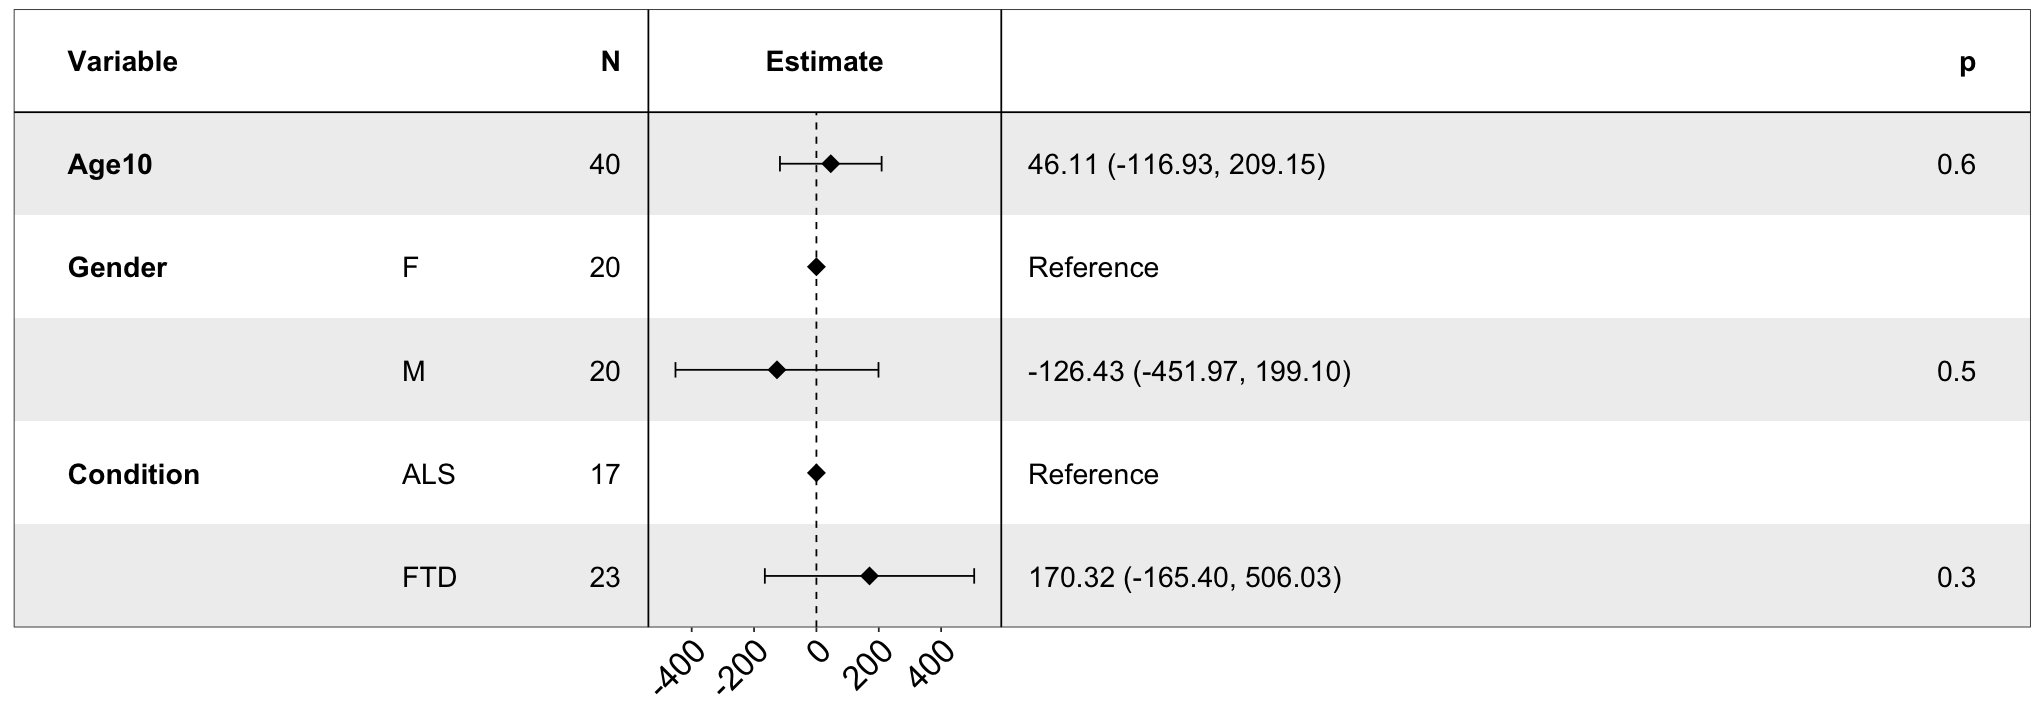

In [84]:
tmp <- df
tmp$Age10 <- tmp$AP/10
reso <- glm(formula = mean ~  Age10 + Gender + Condition, family="gaussian", data=tmp)

reso

library(forestmodel)

options(repr.plot.width=17, repr.plot.height=6)
gf1 <- forest_model(reso,
             #panels=panels,
             theme=theme_forest(),
             format_options = forest_model_format_options(text_size = 6, shape=18),
            ) + gtheme(20) + angle45
gf1

# Predictive Model for Condition

In [85]:
dim(df)
head(df,2)

[1] 40 24

Sample,AP,AO,Gender,group_age,Condition,n_molecules,mean,median,min,⋯,n_4000,m_2000,m_3000,m_4000,prop_2000,prop_3000,prop_4000,mprop_2000,mprop_3000,mprop_4000
<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
125839,65,63,F,64+,FTD,83,1880.500,1261.817,71.53333,⋯,76,25,15,7,0.6987952,0.8192771,0.9156627,0.3012048,0.1807229,0.08433735
128743,76,66,M,64+,FTD,74,2933.664,2785.225,131.88333,⋯,54,54,33,20,0.2702703,0.5540541,0.7297297,0.7297297,0.4459459,0.27027027


In [86]:
summary(df$AP)
table(dff$Condition)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  36.00   56.00   65.00   64.22   72.25   89.00 


ALS FTD 
 17  23 


Call:  glm(formula = y ~ Age10 + Gender + mprop_2000, family = "binomial", 
    data = tmp)

Coefficients:
(Intercept)        Age10      GenderM   mprop_2000  
     2.7997      -0.3776      -0.2728      -1.6663  

Degrees of Freedom: 39 Total (i.e. Null);  36 Residual
Null Deviance:	    54.55 
Residual Deviance: 51.81 	AIC: 59.81

Warning message in recalculate_width_panels(panel_positions, mapped_text = mapped_text, :
“Unable to resize forest panel to be smaller than its heading; consider a smaller text size”


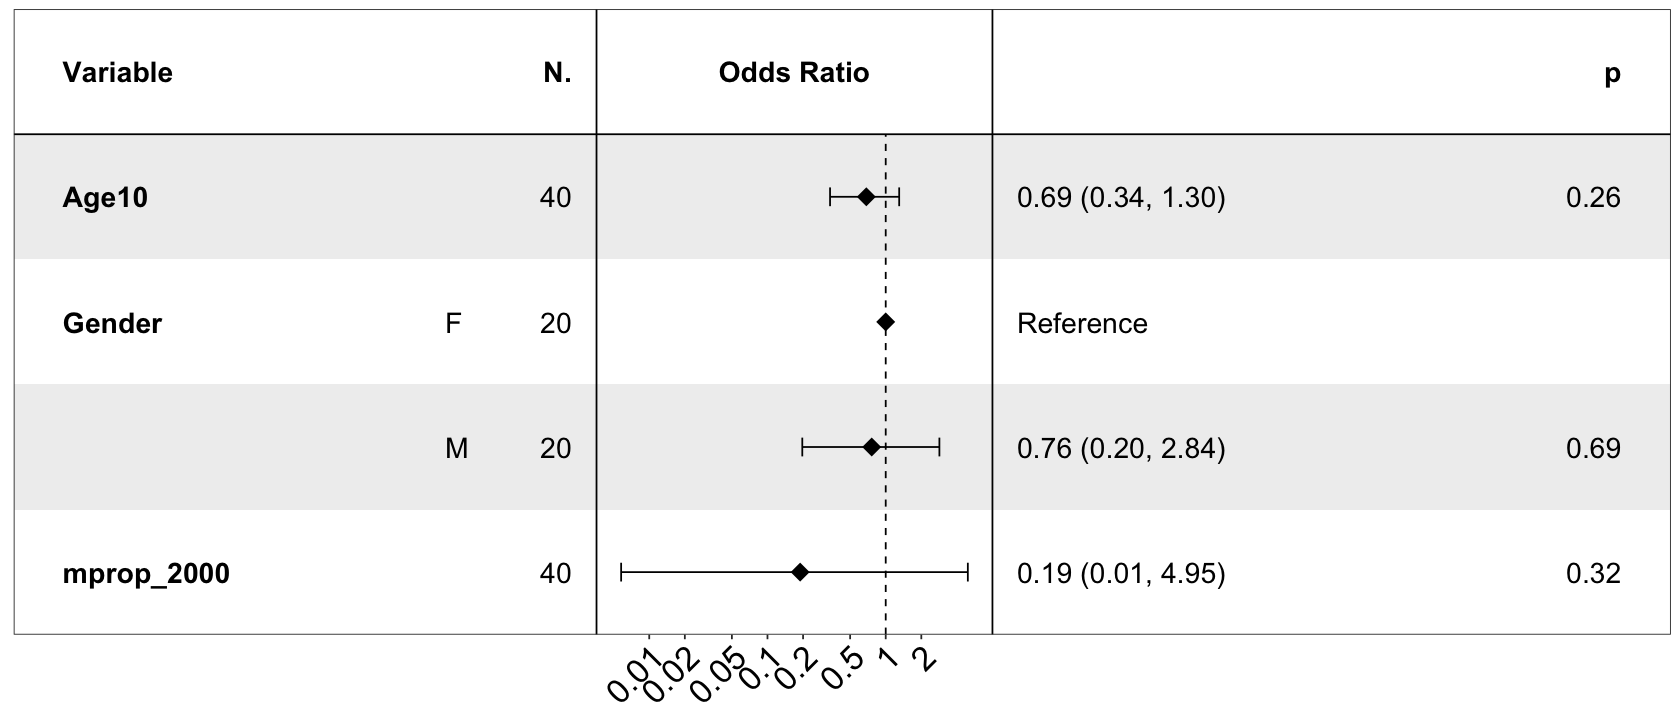

In [87]:
tmp <- dff
tmp$Age10 <- tmp$AP/10
tmp$y <- 0
tmp$y[which(tmp$Condition=="ALS")] <- 1
reso <- glm(formula = y ~  Age10 + Gender + mprop_2000, family="binomial", data=tmp)

reso

library(forestmodel)

options(repr.plot.width=14, repr.plot.height=6)
gf1 <- forest_model(reso,
             panels=panels,
             theme=theme_forest(),
             format_options = forest_model_format_options(text_size = 6, shape=18),
            ) + gtheme(20) + angle45
gf1

# Cohort Characteristics

In [88]:
library(gtsummary)
library(gt)


In [89]:
summary(df$n_molecules)
summary(as.numeric(dc$Molecules_count))

summary(df$mean)
summary(as.numeric(dc$Mean))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  48.00   62.50   72.00   71.28   81.25   92.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  48.00   62.50   72.00   71.28   81.25   92.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  708.1  1430.8  1869.7  1791.1  2041.1  2933.7 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  708.1  1430.8  1869.7  1791.1  2041.1  2933.7 

In [90]:
qq <- df %>% ungroup()
caca <- qq %>% select(AP, Gender, Condition, n_molecules, mean, median, min, max, sd) %>%
  tbl_summary() %>% as_gt()
gtsave(caca, filename = "table1-red.html")

In [91]:
qq <- df %>% ungroup()
caca <- qq %>% select(AP, Gender, Condition, n_molecules, mean, median, min, max, sd) %>%
  tbl_summary(by = Condition) %>% as_gt()
gtsave(caca, filename = "table2-red.html")

In [92]:
qq <- df %>% ungroup()
#caca <- qq %>% select(AP, Gender, Condition, n_molecules, mean, median, min, max, sd) %>%
#  tbl_summary(by = Condition) %>%
#  add_p() %>%
#  bold_labels() %>%
#  as_gt()

caca <- qq %>%
  select(AP, Gender, Condition, n_molecules, mean, median, min, max, sd) %>%
  tbl_summary(
    by = Condition,
    #type = all_continuous() ~ "continuous2",
    #statistic = all_continuous() ~ "{mean} ({sd})",
    missing_text = "Missing"
  ) %>%
  add_p() %>% as_gt()

gtsave(caca, filename = "table3-red.html")

The following warnings were returned during `as_gt()`:
! For variable `AP` (`Condition`) and "estimate", "statistic", "p.value", "conf.low", and "conf.high"
  statistics: impossible de calculer la p-value exacte avec des ex-aequos
! For variable `AP` (`Condition`) and "estimate", "statistic", "p.value", "conf.low", and "conf.high"
  statistics: impossible de calculer les intervalles de confiance exacts avec des ex-aequos
! For variable `n_molecules` (`Condition`) and "estimate", "statistic", "p.value", "conf.low", and
  "conf.high" statistics: impossible de calculer la p-value exacte avec des ex-aequos
! For variable `n_molecules` (`Condition`) and "estimate", "statistic", "p.value", "conf.low", and
  "conf.high" statistics: impossible de calculer les intervalles de confiance exacts avec des
  ex-aequos
